# 2. Data Preprocessing

In [156]:
import pandas as pd
import numpy as np
import os, sys
import gc, re
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## 2.1 Data Overview

In this study, we will use `application_train.csv` as our main training dataset and enrich it using features engineered from other datasets. Therefore, here we will only analyze `application_train.csv` and preprocess it (e.g. handling missing values and categorical data).

In [2]:
data_dir = "../data/"
results_dir = "../results/"

app_train = pd.read_csv(os.path.join(data_dir,'application_train.csv'))
app_test = pd.read_csv(os.path.join(data_dir,'application_test.csv'))

print(f'Training Data Shape: {app_train.shape}')
print(f'Testing Data Shape: {app_test.shape}')

app_test.head()  

Training Data Shape: (307511, 122)
Testing Data Shape: (48744, 121)


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: ylabel='Frequency'>

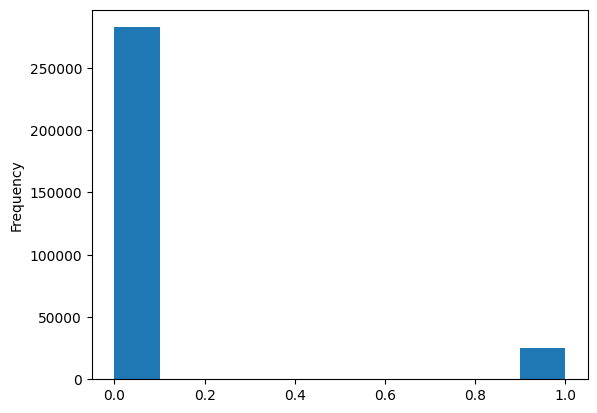

In [3]:
app_train['TARGET'].astype(int).plot.hist()

We found the training dataset very imbalanced.

## 2.2 Input Data Transformation

In [4]:
app_train.dtypes.value_counts()

float64    65
int64      41
object     16
Name: count, dtype: int64

In [5]:
app_train.select_dtypes('object').apply(pd.Series.nunique, axis = 0)

NAME_CONTRACT_TYPE             2
CODE_GENDER                    3
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_TYPE_SUITE                7
NAME_INCOME_TYPE               8
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
OCCUPATION_TYPE               18
WEEKDAY_APPR_PROCESS_START     7
ORGANIZATION_TYPE             58
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
WALLSMATERIAL_MODE             7
EMERGENCYSTATE_MODE            2
dtype: int64

We need to encode categorical features. In this study, we will apply label encoding for categorical features > 2 classes and one-host encoding for binary features.

In [6]:
# LabelEncoder 是 Scikit-learn 提供的一种工具，用于将目标变量（即分类任务中的标签）从离散的类别型数据转换为模型可识别的数值格式。
from sklearn.preprocessing import LabelEncoder

# Create a label encoder object
le = LabelEncoder()
le_count = 0

# Iterate through the columns
for col in app_train:
    if app_train[col].dtype == 'object':
        # If 2 or fewer unique categories
        if len(list(app_train[col].unique())) <= 2:   #特征小于等于2
            # Train on the training data
            le.fit(app_train[col])
            # Transform both training and testing data
            app_train[col] = le.transform(app_train[col])
            app_test[col] = le.transform(app_test[col])
            
            # Keep track of how many columns were label encoded
            le_count += 1
            
print('%d columns were label encoded.' % le_count)

3 columns were label encoded.


In [7]:
# one-hot encoding of categorical variables
app_train = pd.get_dummies(app_train)
app_test = pd.get_dummies(app_test)

print('Training Features shape: ', app_train.shape)
print('Testing Features shape: ', app_test.shape)

Training Features shape:  (307511, 243)
Testing Features shape:  (48744, 239)


Align features in training and testing data.

In [8]:
train_labels = app_train['TARGET']

# Align the training and testing data, keep only columns present in both dataframes
app_train, app_test = app_train.align(app_test, join = 'inner', axis = 1)

# Add the target back in
app_train['TARGET'] = train_labels

print('Training Features shape: ', app_train.shape)
print('Testing Features shape: ', app_test.shape)

Training Features shape:  (307511, 240)
Testing Features shape:  (48744, 239)


## 2.3 Detect and Impute Missing Values

In [9]:
# Function to calculate missing values by column
def missing_values_table(df):
    # Total missing values
    mis_val = df.isnull().sum()

    # Percentage of missing values
    mis_val_percent = 100 * df.isnull().sum() / len(df)

    # Make a table with the results
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

    # Rename the columns
    mis_val_table_ren_columns = mis_val_table.rename(
    columns = {0 : 'Missing Values', 1 : 'Percentage of Total Values'})

    # Sort the table by percentage of missing descending
    mis_val_table_ren_columns = mis_val_table_ren_columns[
        mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
    'Percentage of Total Values', ascending=False).round(1)

    # Print some summary information
    print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"      
        "There are " + str(mis_val_table_ren_columns.shape[0]) +
            " columns that have missing values.")

    # Return the dataframe with missing information
    return mis_val_table_ren_columns

For features with <= 20% missing values, it may be due to mistakes in data preparation and the remaining distribution should still be informative. Therefore, we will impute them with median.

For other features with missing values > 20%, we have two options, either to simply drop them or to impute them and add another "missing" indicator. We decided to print out these features and interpret them first.

In [10]:
missing_value_features = missing_values_table(app_train)

print(len(missing_value_features[missing_value_features['Percentage of Total Values'] <= 20]), "has <=20% missing values")
missing_value_features[missing_value_features['Percentage of Total Values'] > 20]

Your selected dataframe has 240 columns.
There are 61 columns that have missing values.
16 has <=20% missing values


,Missing Values,Percentage of Total Values
COMMONAREA_MODE,214865,69.9
COMMONAREA_MEDI,214865,69.9
COMMONAREA_AVG,214865,69.9
NONLIVINGAPARTMENTS_MODE,213514,69.4
NONLIVINGAPARTMENTS_AVG,213514,69.4
NONLIVINGAPARTMENTS_MEDI,213514,69.4
LIVINGAPARTMENTS_MEDI,210199,68.4
LIVINGAPARTMENTS_AVG,210199,68.4
LIVINGAPARTMENTS_MODE,210199,68.4
FLOORSMIN_MEDI,208642,67.8


It turns out that most features here are related to house/appartment area and car ownership (OWN_CAR_AGE). Therefore, a missing value here may indicate that the applicant don't have a car or a place to live, which can potentially say a lot about their ability to pay their loan. It would be dangerous to simply remove them. Instead, the missing pattern itself would be informative. Therefore, we decided to impute these columns with median and add a corresponding missing indicator to preserve such information.

Note that we should impute the test split using the same imputing value from the training dataset and add the same set of missing indicators for feature consistency and to prevent data leakage.

In [ ]:
# Iterate through the columns with missing values
for col in missing_value_features.index:
    # If missing values are > 20%, add a binary missing indicator
    if missing_value_features.loc[col, 'Percentage of Total Values'] > 20:
        app_train[f'{col}_MISSING'] = app_train[col].isnull().astype(int)
        app_test[f'{col}_MISSING'] = app_test[col].isnull().astype(int)

    # Impute with median
    median_value = app_train[col].median()
    app_train[col].fillna(median_value, inplace=True)
    app_test[col].fillna(median_value, inplace=True)

In [12]:
print('Training Features shape: ', app_train.shape)
print('Testing Features shape: ', app_test.shape)

Training Features shape:  (307511, 285)
Testing Features shape:  (48744, 284)


**Now we have prepared the baseline features (Feature Set A)**

# 3. Feature Engineering

# 3.3.1 Preliminary Exploratory Data Analysis (EDA) - Highly correlated features

The first step of feature engineering is to do some exploratory data analysis such as correlation to see it there're any particularly important features that can potentially be used in manual feature engineering. It may worth paying attention to them when constructing, for example, polynomial features, with the hope that combining these strong predictor will reveal the interaction among them, subsequently exploit their importance to the task, and explore the complicacy of the feature distribution in the dataset.

In [13]:
# Find correlations with the target and sort
correlations = app_train.corr()['TARGET'].sort_values()

# Display correlations
print('Most Positive Correlations:\n', correlations.tail(15))
print('\nMost Negative Correlations:\n', correlations.head(15))

Most Positive Correlations:
 DAYS_REGISTRATION                                    0.041975
OCCUPATION_TYPE_Laborers                             0.043019
FLAG_DOCUMENT_3                                      0.044346
REG_CITY_NOT_LIVE_CITY                               0.044395
FLAG_EMP_PHONE                                       0.045982
NAME_EDUCATION_TYPE_Secondary / secondary special    0.049824
REG_CITY_NOT_WORK_CITY                               0.050994
DAYS_ID_PUBLISH                                      0.051457
CODE_GENDER_M                                        0.054713
DAYS_LAST_PHONE_CHANGE                               0.055218
NAME_INCOME_TYPE_Working                             0.057481
REGION_RATING_CLIENT                                 0.058899
REGION_RATING_CLIENT_W_CITY                          0.060893
DAYS_BIRTH                                           0.078239
TARGET                                               1.000000
Name: TARGET, dtype: float64

Most Negati

In the following, we will analyze the most positively (i.e. `DAYS_BIRTH`) and the most negatively correlated features. Note that three mysterious features named "EXT_SOURCE_x" are all (relatively) strongly correlated with the target. Based on `HomeCredit_columns_description.csv`, we were told that they are "Normalized score from external data source", which could be client credit databases. Without knowing what they actually mean, we decided to analyze all three instead of only `EXT_SOURCE_2` to see, for example, their intra-correlation is also high.

### A peek into `DAYS_BIRTH`

In [14]:
app_train['DAYS_BIRTH'].max()

np.int64(-7489)

By peeking into `DAYS_BIRTH`, we found this feature is strangely all negative. Base on the description, this is "Client's age in days at the time of application" so it makes sense to be negative as it's retrospective. However, for interpretability concern, here we will transform them into positive values.

In [15]:
# Find the correlation of the positive days since birth and target
app_train['DAYS_BIRTH'] = abs(app_train['DAYS_BIRTH'])
app_test['DAYS_BIRTH'] = abs(app_test['DAYS_BIRTH'])

app_train['DAYS_BIRTH'].corr(app_train['TARGET'])

np.float64(-0.07823930830982488)

As customers age, there is a negative correlation with the target (indicator of paying difficulties), meaning that the older the client, the more likely they repay their loans on time. This makes sense as younger clients are still at the beginning of their careers and are less likely to have a highly paid positions, which are usually senior positions, secured. Of course, the correlation is not significant (only -0.078). However, since this is the top most feature and is also interpretable, we think it's still necessary to take this correlation into account when we engineer, say, polynomial features.

### Correlating the most correlated features
Including `DAYS_BIRTH`, `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3`.

Before constructing polynomial features, we should make sure the features used are not by themselves highly correlated. Otherwise, it will introduce redundancy to the model instead of capturing the complicated interaction between them.

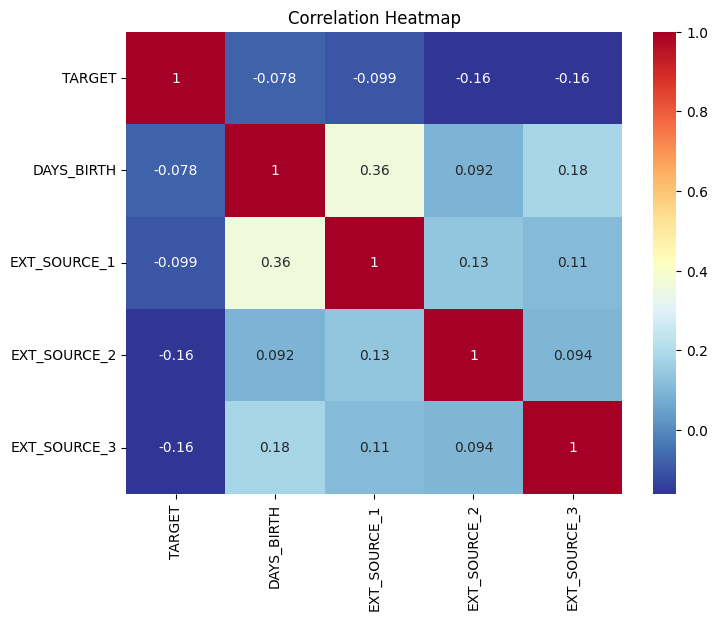

In [16]:
ext_data = app_train[['TARGET', 'DAYS_BIRTH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']]
ext_data_corrs = ext_data.corr()

plt.figure(figsize = (8, 6))

# Heatmap of correlations
sns.heatmap(ext_data_corrs, cmap = plt.cm.RdYlBu_r, annot = True)
plt.title('Correlation Heatmap')
plt.show()

It seems that we are at a safe zone. Note that `EXT_SOURCE_1` and `DAYS_BIRTH` have relatively higher correlation, indicating that age may be one of the scoring factors in that external database. However, since it's at the level of 0.36, we still considered them when we do polynomial features.

# 3.3.2 Manual Feature Engineering

Unlike more complicated tasks such as naturalistic image recognition, where neural nets become powerful and hyperparameter tuning is important, for this type of finance data classification task, where the features are structured and even interpretable, the classification success usually stems from a better feature set instead of a more powerful (and potentially more complicated) model. Feature engineering, in turn, is very important.

Here we will start from manual feature engineering. We first use the best predictors identified in 3.3.1 to construct polynomial features to exploit their intricate interactions. Then, we use domain knowledge (to be honest just our common sense and intuition) to construct domain knowledge features.

### Polynomial Features

In [17]:
# Make a new dataframe for polynomial features
poly_features_train = app_train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH', 'TARGET']]
poly_features_test = app_test[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']]

poly_target = poly_features_train['TARGET']
poly_features_train = poly_features_train.drop(columns = ['TARGET'])

from sklearn.preprocessing import PolynomialFeatures
                                  
# Create the polynomial object with specified degree
poly_transformer = PolynomialFeatures(degree = 3)

# Train the polynomial features
poly_transformer.fit(poly_features_train)

# Transform the features
poly_features_train = poly_transformer.transform(poly_features_train)
poly_features_test = poly_transformer.transform(poly_features_test)
print('Polynomial Features shape (train): ', poly_features_train.shape)
print('Polynomial Features shape (test): ', poly_features_test.shape)

Polynomial Features shape (train):  (307511, 35)
Polynomial Features shape (test):  (48744, 35)


And to check the name of newly created features:

In [18]:
poly_transformer.get_feature_names_out(input_features = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH'])

array(['1', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH',
       'EXT_SOURCE_1^2', 'EXT_SOURCE_1 EXT_SOURCE_2',
       'EXT_SOURCE_1 EXT_SOURCE_3', 'EXT_SOURCE_1 DAYS_BIRTH',
       'EXT_SOURCE_2^2', 'EXT_SOURCE_2 EXT_SOURCE_3',
       'EXT_SOURCE_2 DAYS_BIRTH', 'EXT_SOURCE_3^2',
       'EXT_SOURCE_3 DAYS_BIRTH', 'DAYS_BIRTH^2', 'EXT_SOURCE_1^3',
       'EXT_SOURCE_1^2 EXT_SOURCE_2', 'EXT_SOURCE_1^2 EXT_SOURCE_3',
       'EXT_SOURCE_1^2 DAYS_BIRTH', 'EXT_SOURCE_1 EXT_SOURCE_2^2',
       'EXT_SOURCE_1 EXT_SOURCE_2 EXT_SOURCE_3',
       'EXT_SOURCE_1 EXT_SOURCE_2 DAYS_BIRTH',
       'EXT_SOURCE_1 EXT_SOURCE_3^2',
       'EXT_SOURCE_1 EXT_SOURCE_3 DAYS_BIRTH',
       'EXT_SOURCE_1 DAYS_BIRTH^2', 'EXT_SOURCE_2^3',
       'EXT_SOURCE_2^2 EXT_SOURCE_3', 'EXT_SOURCE_2^2 DAYS_BIRTH',
       'EXT_SOURCE_2 EXT_SOURCE_3^2',
       'EXT_SOURCE_2 EXT_SOURCE_3 DAYS_BIRTH',
       'EXT_SOURCE_2 DAYS_BIRTH^2', 'EXT_SOURCE_3^3',
       'EXT_SOURCE_3^2 DAYS_BIRTH', 'EXT_SOURCE_3 DAYS_BIR

And to check whether the new polynomial features constructed are indeed informative (i.e. high correlation with the target.)

In [19]:
# Create a dataframe of the features 
poly_features_train = pd.DataFrame(poly_features_train, 
                             columns = poly_transformer.get_feature_names_out(['EXT_SOURCE_1', 'EXT_SOURCE_2', 
                                                                         'EXT_SOURCE_3', 'DAYS_BIRTH']))
poly_features_test = pd.DataFrame(poly_features_test, 
                                  columns = poly_transformer.get_feature_names_out(['EXT_SOURCE_1', 'EXT_SOURCE_2', 
                                                                                'EXT_SOURCE_3', 'DAYS_BIRTH']))
# Add in the target
poly_features_train['TARGET'] = poly_target

# Find the correlations with the target
poly_corrs = poly_features_train.corr()['TARGET'].sort_values()

# Display most negative and most positive
print(poly_corrs.head(5))
print(poly_corrs.tail(5))

EXT_SOURCE_2 EXT_SOURCE_3                -0.193939
EXT_SOURCE_1 EXT_SOURCE_2 EXT_SOURCE_3   -0.189605
EXT_SOURCE_2 EXT_SOURCE_3 DAYS_BIRTH     -0.181283
EXT_SOURCE_2^2 EXT_SOURCE_3              -0.176428
EXT_SOURCE_2 EXT_SOURCE_3^2              -0.172282
Name: TARGET, dtype: float64
DAYS_BIRTH     -0.078239
DAYS_BIRTH^2   -0.076672
DAYS_BIRTH^3   -0.074273
TARGET          1.000000
1                    NaN
Name: TARGET, dtype: float64


Prepare dataframes with these polynomial features incorperated. We will compare model's performance with and without these additional features

In [20]:
poly_features_train.head(5)

,1,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH,EXT_SOURCE_1^2,EXT_SOURCE_1 EXT_SOURCE_2,EXT_SOURCE_1 EXT_SOURCE_3,EXT_SOURCE_1 DAYS_BIRTH,EXT_SOURCE_2^2,...,EXT_SOURCE_2^2 EXT_SOURCE_3,EXT_SOURCE_2^2 DAYS_BIRTH,EXT_SOURCE_2 EXT_SOURCE_3^2,EXT_SOURCE_2 EXT_SOURCE_3 DAYS_BIRTH,EXT_SOURCE_2 DAYS_BIRTH^2,EXT_SOURCE_3^3,EXT_SOURCE_3^2 DAYS_BIRTH,EXT_SOURCE_3 DAYS_BIRTH^2,DAYS_BIRTH^3,TARGET
0,1.0,0.083037,0.262949,0.139376,9461.0,0.006895,0.021834,0.011573,785.612748,0.069142,...,0.009637,654.152107,0.005108,346.733022,2.353667e+07,0.002707,183.785678,1.247560e+07,8.468590e+11,1
1,1.0,0.311267,0.622246,0.535276,16765.0,0.096887,0.193685,0.166614,5218.396475,0.387190,...,0.207254,6491.237078,0.178286,5583.975307,1.748916e+08,0.153368,4803.518937,1.504475e+08,4.712058e+12,0
2,1.0,0.505998,0.555912,0.729567,19046.0,0.256034,0.281290,0.369159,9637.236584,0.309038,...,0.225464,5885.942404,0.295894,7724.580288,2.016572e+08,0.388325,10137.567875,2.646504e+08,6.908939e+12,0
3,1.0,0.505998,0.650442,0.535276,19005.0,0.256034,0.329122,0.270849,9616.490669,0.423074,...,0.226462,8040.528832,0.186365,6616.894625,2.349331e+08,0.153368,5445.325225,1.933364e+08,6.864416e+12,0
4,1.0,0.505998,0.322738,0.535276,19932.0,0.256034,0.163305,0.270849,10085.550751,0.104160,...,0.055754,2076.117157,0.092471,3443.335521,1.282190e+08,0.153368,5710.929881,2.126570e+08,7.918677e+12,0


In [128]:
# Merge polynomial features into training dataframe
poly_features_train['SK_ID_CURR'] = app_train['SK_ID_CURR']
app_poly_train = app_train.merge(poly_features_train, on = 'SK_ID_CURR', how = 'left')

# Merge polnomial features into testing dataframe
poly_features_test['SK_ID_CURR'] = app_test['SK_ID_CURR']
app_poly_test = app_test.merge(poly_features_test, on = 'SK_ID_CURR', how = 'left')

# Print out the new shapes
print('Training data with polynomial features shape: ', app_poly_train.shape)
print('Testing data with polynomial features shape:  ', app_poly_test.shape)

Training data with polynomial features shape:  (307511, 320)
Testing data with polynomial features shape:   (48744, 319)


**Now we have created the Feature Set B (baseline+polynomial)**

### Domain Knowledge Features

- CREDIT_INCOME_PERCENT：信贷金额占客户收入的百分比
- ANNUITY_INCOME_PERCENT：贷款年金占客户收入的百分比
- CREDIT_TERM：还款期限（月数）（由于年金是每月应付金额）
- DAYS_EMPLOYED_PERCENT：在职天数占客户年龄的百分比

In [50]:
from sklearn.impute import SimpleImputer
def read_csv_and_impute(file_path, dtype=None):
    df = pd.read_csv(file_path, dtype=dtype)
    imputer = SimpleImputer(strategy='median')
    # impute only numeric columns
    df[df.select_dtypes(include=[np.number]).columns] = imputer.fit_transform(df.select_dtypes(include=[np.number]))
    return df

In [51]:
def get_apps_processed(apps):
    """
    feature engineering for apps
    """

    # 0. Basic Feature Engineering (see the comments above)
    apps['CREDIT_INCOME_PERCENT'] = apps['AMT_CREDIT'] / apps['AMT_INCOME_TOTAL']
    apps['ANNUITY_INCOME_PERCENT'] = apps['AMT_ANNUITY'] / apps['AMT_INCOME_TOTAL']
    apps['CREDIT_TERM'] = apps['AMT_ANNUITY'] / apps['AMT_CREDIT']
    apps['DAYS_EMPLOYED_PERCENT'] = apps['DAYS_EMPLOYED'] / apps['DAYS_BIRTH']

    # 1.EXT_SOURCE_X FEATURE 
    apps['APPS_EXT_SOURCE_MEAN'] = apps[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis = 1)
    apps['APPS_EXT_SOURCE_STD'] = apps[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].std(axis=1)
    apps['APPS_EXT_SOURCE_STD'] = apps['APPS_EXT_SOURCE_STD'].fillna(apps['APPS_EXT_SOURCE_STD'].mean())
    
    # AMT_CREDIT 
    apps['APPS_ANNUITY_CREDIT_RATIO'] = apps['AMT_ANNUITY']/apps['AMT_CREDIT']
    apps['APPS_GOODS_CREDIT_RATIO'] = apps['AMT_GOODS_PRICE']/apps['AMT_CREDIT']
    
    # AMT_INCOME_TOTAL 
    apps['APPS_ANNUITY_INCOME_RATIO'] = apps['AMT_ANNUITY']/apps['AMT_INCOME_TOTAL']
    apps['APPS_CREDIT_INCOME_RATIO'] = apps['AMT_CREDIT']/apps['AMT_INCOME_TOTAL']
    apps['APPS_GOODS_INCOME_RATIO'] = apps['AMT_GOODS_PRICE']/apps['AMT_INCOME_TOTAL']
    apps['APPS_CNT_FAM_INCOME_RATIO'] = apps['AMT_INCOME_TOTAL']/apps['CNT_FAM_MEMBERS']
    
    # DAYS_BIRTH, DAYS_EMPLOYED 
    apps['APPS_EMPLOYED_BIRTH_RATIO'] = apps['DAYS_EMPLOYED']/apps['DAYS_BIRTH']
    apps['APPS_INCOME_EMPLOYED_RATIO'] = apps['AMT_INCOME_TOTAL']/apps['DAYS_EMPLOYED']
    apps['APPS_INCOME_BIRTH_RATIO'] = apps['AMT_INCOME_TOTAL']/apps['DAYS_BIRTH']
    apps['APPS_CAR_BIRTH_RATIO'] = apps['OWN_CAR_AGE'] / apps['DAYS_BIRTH']
    apps['APPS_CAR_EMPLOYED_RATIO'] = apps['OWN_CAR_AGE'] / apps['DAYS_EMPLOYED']
    
    return apps

In [52]:
def get_balance_data():
    pos_dtype = {
        'SK_ID_PREV':np.uint32, 'SK_ID_CURR':np.uint32, 'MONTHS_BALANCE':np.int32, 'SK_DPD':np.int32,
        'SK_DPD_DEF':np.int32, 'CNT_INSTALMENT':np.float32,'CNT_INSTALMENT_FUTURE':np.float32
    }

    install_dtype = {
        'SK_ID_PREV':np.uint32, 'SK_ID_CURR':np.uint32, 'NUM_INSTALMENT_NUMBER':np.int32, 'NUM_INSTALMENT_VERSION':np.float32, 'DAYS_INSTALMENT':np.float32, 'DAYS_ENTRY_PAYMENT':np.float32, 'AMT_INSTALMENT':np.float32, 'AMT_PAYMENT':np.float32
    }

    card_dtype = {
        'SK_ID_PREV':np.uint32, 'SK_ID_CURR':np.uint32, 'MONTHS_BALANCE':np.int16,
        'AMT_CREDIT_LIMIT_ACTUAL':np.int32, 'CNT_DRAWINGS_CURRENT':np.int32, 'SK_DPD':np.int32,'SK_DPD_DEF':np.int32,
        'AMT_BALANCE':np.float32, 'AMT_DRAWINGS_ATM_CURRENT':np.float32, 'AMT_DRAWINGS_CURRENT':np.float32,
        'AMT_DRAWINGS_OTHER_CURRENT':np.float32, 'AMT_DRAWINGS_POS_CURRENT':np.float32, 'AMT_INST_MIN_REGULARITY':np.float32,
        'AMT_PAYMENT_CURRENT':np.float32, 'AMT_PAYMENT_TOTAL_CURRENT':np.float32, 'AMT_RECEIVABLE_PRINCIPAL':np.float32,
        'AMT_RECIVABLE':np.float32, 'AMT_TOTAL_RECEIVABLE':np.float32, 'CNT_DRAWINGS_ATM_CURRENT':np.float32,
        'CNT_DRAWINGS_OTHER_CURRENT':np.float32, 'CNT_DRAWINGS_POS_CURRENT':np.float32, 'CNT_INSTALMENT_MATURE_CUM':np.float32
    }

    pos_bal = read_csv_and_impute(os.path.join(data_dir,'POS_CASH_balance.csv'), dtype=pos_dtype)
    install = read_csv_and_impute(os.path.join(data_dir,'installments_payments.csv'), dtype=install_dtype)
    card_bal = read_csv_and_impute(os.path.join(data_dir, 'credit_card_balance.csv'), dtype=card_dtype)

    return pos_bal, install, card_bal

In [53]:
def get_prev_processed(prev):
    """
    feature engineering 
    for previouse application credit history
    """
    prev['PREV_CREDIT_DIFF'] = prev['AMT_APPLICATION'] - prev['AMT_CREDIT']
    prev['PREV_GOODS_DIFF'] = prev['AMT_APPLICATION'] - prev['AMT_GOODS_PRICE']
    prev['PREV_CREDIT_APPL_RATIO'] = prev['AMT_CREDIT']/prev['AMT_APPLICATION']
    # prev['PREV_ANNUITY_APPL_RATIO'] = prev['AMT_ANNUITY']/prev['AMT_APPLICATION']
    prev['PREV_GOODS_APPL_RATIO'] = prev['AMT_GOODS_PRICE']/prev['AMT_APPLICATION']

    # Data Cleansing
    prev['DAYS_FIRST_DRAWING'].replace(365243, np.nan, inplace= True)
    prev['DAYS_FIRST_DUE'].replace(365243, np.nan, inplace= True)
    prev['DAYS_LAST_DUE_1ST_VERSION'].replace(365243, np.nan, inplace= True)
    prev['DAYS_LAST_DUE'].replace(365243, np.nan, inplace= True)
    prev['DAYS_TERMINATION'].replace(365243, np.nan, inplace= True)

    # substraction between DAYS_LAST_DUE_1ST_VERSION and DAYS_LAST_DUE
    prev['PREV_DAYS_LAST_DUE_DIFF'] = prev['DAYS_LAST_DUE_1ST_VERSION'] - prev['DAYS_LAST_DUE']

    # 1.Calculate the interest rate
    all_pay = prev['AMT_ANNUITY'] * prev['CNT_PAYMENT']
    prev['PREV_INTERESTS_RATE'] = (all_pay/prev['AMT_CREDIT'] - 1)/prev['CNT_PAYMENT']

    return prev

def get_prev_amt_agg(prev):
    """
    feature engineering for the previous credit appliction
    """

    agg_dict = {
      'SK_ID_CURR':['count'],
      'AMT_CREDIT':['mean', 'max', 'sum'],
      'AMT_ANNUITY':['mean', 'max', 'sum'], 
      'AMT_APPLICATION':['mean', 'max', 'sum'],
      'AMT_DOWN_PAYMENT':['mean', 'max', 'sum'],
      'AMT_GOODS_PRICE':['mean', 'max', 'sum'],
      'RATE_DOWN_PAYMENT': ['min', 'max', 'mean'],
      'DAYS_DECISION': ['min', 'max', 'mean'],
      'CNT_PAYMENT': ['mean', 'sum'],
        
      'PREV_CREDIT_DIFF':['mean', 'max', 'sum'], 
      'PREV_CREDIT_APPL_RATIO':['mean', 'max'],
      'PREV_GOODS_DIFF':['mean', 'max', 'sum'],
      'PREV_GOODS_APPL_RATIO':['mean', 'max'],
      'PREV_DAYS_LAST_DUE_DIFF':['mean', 'max', 'sum'],
      'PREV_INTERESTS_RATE':['mean', 'max']
    }

    prev_group = prev.groupby('SK_ID_CURR')
    prev_amt_agg = prev_group.agg(agg_dict)

    # multi index 
    prev_amt_agg.columns = ["PREV_"+ "_".join(x).upper() for x in prev_amt_agg.columns.ravel()]

    return prev_amt_agg

def get_prev_refused_appr_agg(prev):
    """
    PREV_APPROVED_COUNT : Credit application approved count
    PREV_REFUSED_COUNT :  Credit application refused count
    """
    prev_refused_appr_group = prev[prev['NAME_CONTRACT_STATUS'].isin(['Approved', 'Refused'])].groupby([ 'SK_ID_CURR', 'NAME_CONTRACT_STATUS'])
    # unstack() 
    prev_refused_appr_agg = prev_refused_appr_group['SK_ID_CURR'].count().unstack()

    # rename column 
    prev_refused_appr_agg.columns = ['PREV_APPROVED_COUNT', 'PREV_REFUSED_COUNT' ]

    # NaN
    prev_refused_appr_agg = prev_refused_appr_agg.fillna(0)

    return prev_refused_appr_agg


# DAYS_DECISION
def get_prev_days365_agg(prev):
    """
    DAYS_DESCISION means How many days have been take since the previous credit application made.
    Somehow this feature is important.
    """
    cond_days365 = prev['DAYS_DECISION'] > -365
    prev_days365_group = prev[cond_days365].groupby('SK_ID_CURR')
    agg_dict = {
      'SK_ID_CURR':['count'],
      'AMT_CREDIT':['mean', 'max', 'sum'],
      'AMT_ANNUITY':['mean', 'max', 'sum'], 
      'AMT_APPLICATION':['mean', 'max', 'sum'],
      'AMT_DOWN_PAYMENT':['mean', 'max', 'sum'],
      'AMT_GOODS_PRICE':['mean', 'max', 'sum'],
      'RATE_DOWN_PAYMENT': ['min', 'max', 'mean'],
      'DAYS_DECISION': ['min', 'max', 'mean'],
      'CNT_PAYMENT': ['mean', 'sum'],
      
      'PREV_CREDIT_DIFF':['mean', 'max', 'sum'], 
      'PREV_CREDIT_APPL_RATIO':['mean', 'max'],
      'PREV_GOODS_DIFF':['mean', 'max', 'sum'],
      'PREV_GOODS_APPL_RATIO':['mean', 'max'],
      'PREV_DAYS_LAST_DUE_DIFF':['mean', 'max', 'sum'],
      'PREV_INTERESTS_RATE':['mean', 'max']
    }

    prev_days365_agg = prev_days365_group.agg(agg_dict)

    # multi index 
    prev_days365_agg.columns = ["PREV_D365_"+ "_".join(x).upper() for x in prev_days365_agg.columns.ravel()]

    return prev_days365_agg

def get_prev_agg(prev):
    prev = get_prev_processed(prev)
    prev_amt_agg = get_prev_amt_agg(prev)
    prev_refused_appr_agg = get_prev_refused_appr_agg(prev)
    prev_days365_agg = get_prev_days365_agg(prev)
    
    # prev_amt_agg
    prev_agg = prev_amt_agg.merge(prev_refused_appr_agg, on='SK_ID_CURR', how='left')
    prev_agg = prev_agg.merge(prev_days365_agg, on='SK_ID_CURR', how='left')
    # SK_ID_CURR APPROVED_COUNT REFUSED_COUNT
    prev_agg['PREV_REFUSED_RATIO'] = prev_agg['PREV_REFUSED_COUNT']/prev_agg['PREV_SK_ID_CURR_COUNT']
    prev_agg['PREV_APPROVED_RATIO'] = prev_agg['PREV_APPROVED_COUNT']/prev_agg['PREV_SK_ID_CURR_COUNT']
    # 'PREV_REFUSED_COUNT', 'PREV_APPROVED_COUNT' drop 
    prev_agg = prev_agg.drop(['PREV_REFUSED_COUNT', 'PREV_APPROVED_COUNT'], axis=1)
    
    return prev_agg

In [54]:
import pandas as pd

def get_bureau_processed(bureau):
    """原始信贷数据预处理，生成衍生特征"""
    bureau['BUREAU_ENDDATE_FACT_DIFF'] = bureau['DAYS_CREDIT_ENDDATE'] - bureau['DAYS_ENDDATE_FACT']
    bureau['BUREAU_CREDIT_FACT_DIFF'] = bureau['DAYS_CREDIT'] - bureau['DAYS_ENDDATE_FACT']
    bureau['BUREAU_CREDIT_ENDDATE_DIFF'] = bureau['DAYS_CREDIT'] - bureau['DAYS_CREDIT_ENDDATE']
  
    bureau['BUREAU_CREDIT_DEBT_RATIO'] = bureau['AMT_CREDIT_SUM_DEBT'] / bureau['AMT_CREDIT_SUM']
    bureau['BUREAU_CREDIT_DEBT_DIFF'] = bureau['AMT_CREDIT_SUM_DEBT'] - bureau['AMT_CREDIT_SUM']
    
    bureau['BUREAU_IS_DPD'] = bureau['CREDIT_DAY_OVERDUE'].apply(lambda x: 1 if x > 0 else 0)
    bureau['BUREAU_IS_DPD_OVER120'] = bureau['CREDIT_DAY_OVERDUE'].apply(lambda x: 1 if x > 120 else 0)
    
    return bureau

def aggregate_bureau(bureau, filter_condition=None, prefix='BUREAU'):
    """
    通用的bureau数据聚合函数
    
    参数:
        bureau: 预处理后的bureau DataFrame
        filter_condition: 筛选条件（布尔Series），None表示不筛选
        prefix: 聚合特征的前缀名
        
    返回:
        按SK_ID_CURR聚合后的DataFrame
    """
    # 应用筛选条件
    if filter_condition is not None:
        filtered_bureau = bureau[filter_condition].copy()
    else:
        filtered_bureau = bureau.copy()
    
    # 定义聚合字典（所有聚合函数共用）
    agg_dict = {
        'SK_ID_BUREAU': ['count'],
        'DAYS_CREDIT': ['min', 'max', 'mean'],
        'CREDIT_DAY_OVERDUE': ['min', 'max', 'mean'],
        'DAYS_CREDIT_ENDDATE': ['min', 'max', 'mean'],
        'DAYS_ENDDATE_FACT': ['min', 'max', 'mean'],
        'AMT_CREDIT_MAX_OVERDUE': ['max', 'mean'],
        'AMT_CREDIT_SUM': ['max', 'mean', 'sum'],
        'AMT_CREDIT_SUM_DEBT': ['max', 'mean', 'sum'],
        'AMT_CREDIT_SUM_OVERDUE': ['max', 'mean', 'sum'],
        'AMT_ANNUITY': ['max', 'mean', 'sum'],

        'BUREAU_ENDDATE_FACT_DIFF': ['min', 'max', 'mean'],
        'BUREAU_CREDIT_FACT_DIFF': ['min', 'max', 'mean'],
        'BUREAU_CREDIT_ENDDATE_DIFF': ['min', 'max', 'mean'],
        'BUREAU_CREDIT_DEBT_RATIO': ['min', 'max', 'mean'],
        'BUREAU_CREDIT_DEBT_DIFF': ['min', 'max', 'mean'],
        'BUREAU_IS_DPD': ['mean', 'sum'],
        'BUREAU_IS_DPD_OVER120': ['mean', 'sum']
    }
    
    # 按用户ID分组聚合
    grouped = filtered_bureau.groupby('SK_ID_CURR').agg(agg_dict)
    
    # 重命名列名
    grouped.columns = [f'{prefix}_{"_".join(col).upper()}' for col in grouped.columns.ravel()]
    
    # 重置索引，将SK_ID_CURR从索引变为列
    return grouped.reset_index()

def get_bureau_bal_agg(bureau, bureau_bal):
    """处理信贷余额月度记录的聚合"""
    # 关联获取用户ID
    bureau_bal = bureau_bal.merge(bureau[['SK_ID_CURR', 'SK_ID_BUREAU']], on='SK_ID_BUREAU', how='left')
    
    # 衍生逾期特征
    bureau_bal['BUREAU_BAL_IS_DPD'] = bureau_bal['STATUS'].apply(lambda x: 1 if x in ['1','2','3','4','5'] else 0)
    bureau_bal['BUREAU_BAL_IS_DPD_OVER120'] = bureau_bal['STATUS'].apply(lambda x: 1 if x == '5' else 0)
    
    # 定义聚合字典
    agg_dict = {
        'SK_ID_CURR': ['count'],
        'MONTHS_BALANCE': ['min', 'max', 'mean'],
        'BUREAU_BAL_IS_DPD': ['mean', 'sum'],
        'BUREAU_BAL_IS_DPD_OVER120': ['mean', 'sum']
    }
    
    # 分组聚合
    grouped = bureau_bal.groupby('SK_ID_CURR').agg(agg_dict)
    grouped.columns = [f'BUREAU_BAL_{"_".join(col).upper()}' for col in grouped.columns.ravel()]
    
    return grouped.reset_index()

def get_bureau_agg(bureau, bureau_bal):
    """整合所有聚合特征"""
    # 预处理数据
    processed_bureau = get_bureau_processed(bureau)
    
    # 使用通用聚合函数生成各类聚合特征
    bureau_day_amt_agg = aggregate_bureau(processed_bureau, prefix='BUREAU')
    bureau_active_agg = aggregate_bureau(
        processed_bureau, 
        filter_condition=processed_bureau['CREDIT_ACTIVE'] == 'Active',
        prefix='BUREAU_ACT'
    )
    bureau_days750_agg = aggregate_bureau(
        processed_bureau, 
        filter_condition=processed_bureau['DAYS_CREDIT'] > -750,
        prefix='BUREAU_DAYS750'  # 修正了原代码中的命名问题
    )
    
    # 处理余额数据聚合
    bureau_bal_agg = get_bureau_bal_agg(processed_bureau, bureau_bal)
    
    # 合并所有特征
    bureau_agg = bureau_day_amt_agg.merge(bureau_active_agg, on='SK_ID_CURR', how='left')
    bureau_agg = bureau_agg.merge(bureau_bal_agg, on='SK_ID_CURR', how='left')
    bureau_agg = bureau_agg.merge(bureau_days750_agg, on='SK_ID_CURR', how='left')
    
    # 衍生比例特征
    bureau_agg['BUREAU_ACT_IS_DPD_RATIO'] = bureau_agg['BUREAU_ACT_BUREAU_IS_DPD_SUM'] / bureau_agg['BUREAU_SK_ID_BUREAU_COUNT']
    bureau_agg['BUREAU_ACT_IS_DPD_OVER120_RATIO'] = bureau_agg['BUREAU_ACT_BUREAU_IS_DPD_OVER120_SUM'] / bureau_agg['BUREAU_SK_ID_BUREAU_COUNT']
    
    return bureau_agg

以上流程解释：
这段 Python 代码是信贷数据（Bureau 数据）的特征工程处理流程，核心目标是从原始的信贷记录（bureau表）和信贷余额记录（bureau_bal表）中提取、加工特征，最终生成以 “用户 ID（SK_ID_CURR）” 为维度的聚合特征表，用于后续的信贷风险建模（如贷款违约预测）。

In [55]:
import pandas as pd

def process_pos_bal_features(pos_bal):
    """预处理POS余额数据，生成衍生特征"""
    # 生成逾期标记特征（仅保留有用的特征衍生）
    pos_bal['POS_IS_DPD'] = pos_bal['SK_DPD'].apply(lambda x: 1 if x > 0 else 0)
    pos_bal['POS_IS_DPD_UNDER_120'] = pos_bal['SK_DPD'].apply(lambda x: 1 if (x > 0) & (x < 120) else 0)
    pos_bal['POS_IS_DPD_OVER_120'] = pos_bal['SK_DPD'].apply(lambda x: 1 if x >= 120 else 0)
    return pos_bal

def aggregate_pos_data(pos_data, filter_condition=None, prefix='POS'):
    """通用的POS数据聚合函数"""
    # 应用筛选条件
    if filter_condition is not None:
        filtered_data = pos_data[filter_condition].copy()
    else:
        filtered_data = pos_data.copy()
    
    # 定义聚合字典（只定义一次）
    agg_dict = {
        'SK_ID_CURR': ['count'],
        'MONTHS_BALANCE': ['min', 'mean', 'max'],
        'SK_DPD': ['min', 'max', 'mean', 'sum'],
        'CNT_INSTALMENT': ['min', 'max', 'mean', 'sum'],
        'CNT_INSTALMENT_FUTURE': ['min', 'max', 'mean', 'sum'],
        'POS_IS_DPD': ['mean', 'sum'],
        'POS_IS_DPD_UNDER_120': ['mean', 'sum'],
        'POS_IS_DPD_OVER_120': ['mean', 'sum']
    }
    
    # 分组聚合
    grouped = filtered_data.groupby('SK_ID_CURR').agg(agg_dict)
    
    # 重命名列名（修复重复前缀问题）
    grouped.columns = [f'{prefix}_{"_".join(col).upper()}' for col in grouped.columns.ravel()]
    
    return grouped.reset_index()

def get_pos_bal_agg(pos_bal):
    """优化后的POS余额聚合函数，消除了冗余代码"""
    # 预处理数据（仅保留必要的特征衍生）
    processed_pos = process_pos_bal_features(pos_bal)
    
    # 使用通用聚合函数进行全量数据聚合
    pos_bal_agg = aggregate_pos_data(processed_pos, prefix='POS')
    
    # 使用通用聚合函数进行近20个月数据聚合
    cond_months = processed_pos['MONTHS_BALANCE'] > -20
    pos_bal_m20_agg = aggregate_pos_data(processed_pos, cond_months, 'POS_M20')
    
    # 合并聚合结果
    pos_bal_agg = pos_bal_agg.merge(pos_bal_m20_agg, on='SK_ID_CURR', how='left')
    
    return pos_bal_agg

以上流程解释：
这段 Python 代码是POS 机分期付款余额数据（pos_bal表）的特征工程处理流程，核心目标是从用户的 POS 机信贷月度记录中提取、衍生逾期行为和分期状态特征，并按 “用户 ID（SK_ID_CURR）” 聚合，最终生成用于信贷风险建模的用户级 POS 信贷特征表。

In [56]:
import pandas as pd

def get_install_processed(install):
    """预处理分期付款数据，生成衍生特征"""
    # 计算还款差异和比例
    install['AMT_DIFF'] = install['AMT_INSTALMENT'] - install['AMT_PAYMENT']
    install['AMT_RATIO'] = (install['AMT_PAYMENT'] + 1) / (install['AMT_INSTALMENT'] + 1)  # +1避免除零
    
    # 计算逾期天数
    install['SK_DPD'] = install['DAYS_ENTRY_PAYMENT'] - install['DAYS_INSTALMENT']
    
    # 生成逾期标记特征
    install['INS_IS_DPD'] = install['SK_DPD'].apply(lambda x: 1 if x > 0 else 0)
    install['INS_IS_DPD_UNDER_120'] = install['SK_DPD'].apply(lambda x: 1 if (x > 0) & (x < 120) else 0)
    install['INS_IS_DPD_OVER_120'] = install['SK_DPD'].apply(lambda x: 1 if x >= 120 else 0)
    
    return install

def aggregate_installments(install, filter_condition=None, prefix='INS'):
    """
    通用的分期付款数据聚合函数
    
    参数:
        install: 预处理后的分期付款DataFrame
        filter_condition: 筛选条件（布尔Series），None表示不筛选
        prefix: 聚合特征的前缀名
        
    返回:
        按SK_ID_CURR聚合后的DataFrame
    """
    # 应用筛选条件
    if filter_condition is not None:
        filtered_install = install[filter_condition].copy()
    else:
        filtered_install = install.copy()
    
    # 定义聚合字典（所有场景共用）
    agg_dict = {
        'SK_ID_CURR': ['count'],
        'NUM_INSTALMENT_VERSION': ['nunique'],
        'DAYS_ENTRY_PAYMENT': ['mean', 'max', 'sum'],
        'DAYS_INSTALMENT': ['mean', 'max', 'sum'],
        'AMT_INSTALMENT': ['mean', 'max', 'sum'],
        'AMT_PAYMENT': ['mean', 'max', 'sum'],
        'AMT_DIFF': ['mean', 'min', 'max', 'sum'],
        'AMT_RATIO': ['mean', 'max'],
        'SK_DPD': ['mean', 'min', 'max'],
        'INS_IS_DPD': ['mean', 'sum'],
        'INS_IS_DPD_UNDER_120': ['mean', 'sum'],
        'INS_IS_DPD_OVER_120': ['mean', 'sum']
    }
    
    # 分组聚合
    grouped = filtered_install.groupby('SK_ID_CURR').agg(agg_dict)
    
    # 重命名列名（修复原代码中重复前缀的问题）
    grouped.columns = [f'{prefix}_' + '_'.join(col).upper() for col in grouped.columns.ravel()]
    
    # 重置索引
    return grouped.reset_index()

def get_install_agg(install):
    """整合所有分期付款数据的最终聚合函数"""
    # 预处理数据
    processed_install = get_install_processed(install)
    
    # 使用通用聚合函数生成特征
    # 1. 全量数据聚合
    install_agg = aggregate_installments(processed_install, prefix='INS')
    
    # 2. 近365天数据聚合
    cond_day = processed_install['DAYS_ENTRY_PAYMENT'] >= -365
    install_d365_agg = aggregate_installments(
        processed_install, 
        filter_condition=cond_day, 
        prefix='INS_D365'
    )
    
    # 合并聚合结果
    install_agg = install_agg.merge(install_d365_agg, on='SK_ID_CURR', how='left')
    
    return install_agg

以上流程解释：
这段代码是对分期付款记录数据（install表）的特征工程处理，核心目的是从用户的分期付款记录中提取还款行为、逾期状态等特征，并按用户 ID（SK_ID_CURR）聚合，生成用于信贷风险评估的用户级分期付款特征表。

In [57]:
import pandas as pd

def process_card_bal_features(card_bal):
    """预处理信用卡数据，生成衍生特征"""
    # 避免除以0的风险（当额度为0时用1替代）
    limit = card_bal['AMT_CREDIT_LIMIT_ACTUAL'].replace(0, 1)
    
    # 计算额度使用比例特征
    card_bal['BALANCE_LIMIT_RATIO'] = card_bal['AMT_BALANCE'] / limit
    card_bal['DRAWING_LIMIT_RATIO'] = card_bal['AMT_DRAWINGS_CURRENT'] / limit
    
    # 生成逾期标记特征
    card_bal['CARD_IS_DPD'] = card_bal['SK_DPD'].apply(lambda x: 1 if x > 0 else 0)
    card_bal['CARD_IS_DPD_UNDER_120'] = card_bal['SK_DPD'].apply(
        lambda x: 1 if (x > 0) & (x < 120) else 0
    )
    card_bal['CARD_IS_DPD_OVER_120'] = card_bal['SK_DPD'].apply(
        lambda x: 1 if x >= 120 else 0
    )
    
    return card_bal

def aggregate_card_data(card_data, filter_condition=None, prefix='CARD'):
    """通用的信用卡数据聚合函数"""
    # 应用筛选条件
    if filter_condition is not None:
        filtered_data = card_data[filter_condition].copy()
    else:
        filtered_data = card_data.copy()
    
    # 聚合字典（只定义一次，所有场景共用）
    agg_dict = {
        'SK_ID_CURR': ['count'],
        'AMT_BALANCE': ['max'],
        'AMT_CREDIT_LIMIT_ACTUAL': ['max'],
        'AMT_DRAWINGS_ATM_CURRENT': ['max', 'sum'],
        'AMT_DRAWINGS_CURRENT': ['max', 'sum'],
        'AMT_DRAWINGS_POS_CURRENT': ['max', 'sum'],
        'AMT_INST_MIN_REGULARITY': ['max', 'mean'],
        'AMT_PAYMENT_TOTAL_CURRENT': ['max', 'sum'],
        'AMT_TOTAL_RECEIVABLE': ['max', 'mean'],
        'CNT_DRAWINGS_ATM_CURRENT': ['max', 'sum'],
        'CNT_DRAWINGS_CURRENT': ['max', 'mean', 'sum'],
        'CNT_DRAWINGS_POS_CURRENT': ['mean'],
        'SK_DPD': ['mean', 'max', 'sum'],
        'BALANCE_LIMIT_RATIO': ['min', 'max'],
        'DRAWING_LIMIT_RATIO': ['min', 'max'],
        'CARD_IS_DPD': ['mean', 'sum'],
        'CARD_IS_DPD_UNDER_120': ['mean', 'sum'],
        'CARD_IS_DPD_OVER_120': ['mean', 'sum']
    }
    
    # 分组聚合
    grouped = filtered_data.groupby('SK_ID_CURR').agg(agg_dict)
    
    # 重命名列名（修复重复前缀问题）
    grouped.columns = [f'{prefix}_{"_".join(col).upper()}' for col in grouped.columns.ravel()]
    
    return grouped.reset_index()

def get_card_bal_agg(card_bal):
    """优化后的信用卡余额聚合函数，消除冗余代码"""
    # 预处理数据
    processed_card = process_card_bal_features(card_bal)
    
    # 全量数据聚合
    card_bal_agg = aggregate_card_data(processed_card, prefix='CARD')
    
    # 近3个月数据聚合
    cond_month = processed_card['MONTHS_BALANCE'] >= -3
    card_bal_m3_agg = aggregate_card_data(processed_card, cond_month, 'CARD_M3')
    
    # 合并聚合结果（仅需一次reset_index）
    card_bal_agg = card_bal_agg.merge(card_bal_m3_agg, on='SK_ID_CURR', how='left')
    
    return card_bal_agg

以上流程解释：
这段代码是对信用卡月度余额数据（card_bal表）的特征工程处理流程，核心目标是从用户的信用卡月度使用记录中提取 “额度使用”“消费行为”“逾期状态” 等关键特征，并按用户 ID（SK_ID_CURR）聚合，最终生成用于信贷风险评估的用户级信用卡特征表。

#### Prepare Feature Set C (baseline + domain)

In [58]:
def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)

    end_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))

    return df

In [ ]:
def get_dataset(app_train_preprocessed, app_test_preprocessed):
    """
    load datasets
    1.app_train_preprocessed - train dataset preprocessed in section 2
    2.app_test_preprocessed - test datasets preprocessed in section 2
    3.apps - concatenated app_train, app_test
    4.pos_bal - POS_CACHE
    5.install - installments_payments
    6.card_bal - Credit Card
    """
    app_train_preprocessed = reduce_mem_usage(app_train_preprocessed)
    app_test_preprocessed = reduce_mem_usage(app_test_preprocessed)
    # we temporarily concatenate the train and test dataset for consistent feature engineering procedures
    # they will be separated later
    apps = pd.concat([app_train_preprocessed, app_test_preprocessed])

    prev = read_csv_and_impute(os.path.join(data_dir,'previous_application.csv'))
    prev = reduce_mem_usage(prev)
    bureau = read_csv_and_impute(os.path.join(data_dir,'bureau.csv'))
    bureau = reduce_mem_usage(bureau)
    bureau_bal = read_csv_and_impute(os.path.join(data_dir,'bureau_balance.csv'))
    bureau_bal = reduce_mem_usage(bureau_bal)

    pos_bal, install, card_bal = get_balance_data()

    return apps, prev, bureau, bureau_bal, pos_bal, install, card_bal

In [ ]:
# apps prev_agg, bureau_agg, pos_bal_agg, install_agg, card_bal_agg
def get_apps_all_with_all_agg(apps, prev, bureau, bureau_bal, pos_bal, install, card_bal):
    """
    Description :
    1.Data preparation , aggregation 
    2.produce the finalized result
    """
    apps_all =  get_apps_processed(apps)
    prev_agg = get_prev_agg(prev)
    bureau_agg = get_bureau_agg(bureau, bureau_bal)
    pos_bal_agg = get_pos_bal_agg(pos_bal)
    install_agg = get_install_agg(install)
    card_bal_agg = get_card_bal_agg(card_bal)
    print('prev_agg shape:', prev_agg.shape, 'bureau_agg shape:', bureau_agg.shape )
    print('pos_bal_agg shape:', pos_bal_agg.shape, 'install_agg shape:', install_agg.shape, 'card_bal_agg shape:', card_bal_agg.shape)
    print('features shape before merge shape:', apps_all.shape)

    # Join with apps_all
    apps_all = apps_all.merge(prev_agg, on='SK_ID_CURR', how='left')
    apps_all = apps_all.merge(bureau_agg, on='SK_ID_CURR', how='left')
    apps_all = apps_all.merge(pos_bal_agg, on='SK_ID_CURR', how='left')
    apps_all = apps_all.merge(install_agg, on='SK_ID_CURR', how='left')
    apps_all = apps_all.merge(card_bal_agg, on='SK_ID_CURR', how='left')

    print('features shape after merge:', apps_all.shape)

    return apps_all

# Re-separate the train and test splits
def get_apps_all_train_test(apps_all):
    apps_all_train = apps_all[~apps_all['TARGET'].isnull()]
    apps_all_test = apps_all[apps_all['TARGET'].isnull()]

    apps_all_test = apps_all_test.drop('TARGET', axis=1)
    
    return apps_all_train, apps_all_test

def get_apps_all_encoded(apps_all):
    object_columns = apps_all.dtypes[apps_all.dtypes == 'object'].index.tolist()
    for column in object_columns:
        apps_all[column] = pd.factorize(apps_all[column])[0]
    
    return apps_all

In [72]:
apps, prev, bureau, bureau_bal, pos_bal, install, card_bal = get_dataset(app_train, app_test)
apps_domain = get_apps_all_with_all_agg(apps, prev, bureau, bureau_bal, pos_bal, install, card_bal)
app_domain_train, app_domain_test = get_apps_all_train_test(apps_domain)
# del apps,prev,bureau,bureau_bal,pos_bal,install,card_bal
gc.collect()

Memory usage after optimization is: 107.34 MB
Decreased by 0.0%
Memory usage after optimization is: 16.97 MB
Decreased by 0.0%
Memory usage after optimization is: 312.20 MB
Decreased by 33.8%
Memory usage after optimization is: 111.31 MB
Decreased by 50.0%
Memory usage after optimization is: 364.49 MB
Decreased by 41.7%
prev_agg shape: (338857, 80) bureau_agg shape: (305811, 149)
pos_bal_agg shape: (337252, 45) install_agg shape: (339587, 59) card_bal_agg shape: (103558, 69)
features shape before merge shape: (356255, 302)
features shape after merge: (356255, 700)


1295

In [ ]:
apps_domain_train_orig, apps_domain_test_orig = app_domain_train.copy(), app_domain_test.copy()

In [105]:
app_domain_train = apps_domain_train_orig.copy()
app_domain_test = apps_domain_test_orig.copy()

In [106]:
# postprocessing - missing value imputation
from sklearn.impute import SimpleImputer

app_domain_train_target = app_domain_train[['SK_ID_CURR','TARGET']]
app_domain_train = app_domain_train.drop(columns = ['TARGET'])

app_domain_train = pd.DataFrame(app_domain_train.replace([np.inf, -np.inf],np.nan))
app_domain_test = pd.DataFrame(app_domain_test.replace([np.inf, -np.inf],np.nan))

In [107]:
imputer = SimpleImputer(missing_values=np.nan, strategy='median')

app_domain_train[app_domain_train.select_dtypes(include=[np.number]).columns] = imputer.fit_transform(app_domain_train.select_dtypes(include=[np.number]))
app_domain_test[app_domain_test.select_dtypes(include=[np.number]).columns] = imputer.transform(app_domain_test.select_dtypes(include=[np.number]))

app_domain_train = app_domain_train.merge(app_domain_train_target, on='SK_ID_CURR', how='left')

# Check the shapes to ensure consistency
print('Training data shape after imputation:', app_domain_train.shape)
print('Testing data shape after imputation:', app_domain_test.shape)

Training data shape after imputation: (307511, 700)
Testing data shape after imputation: (48744, 699)


**Now we have prepared the Feature Set C (baseline+domain)**.

**Finally the Feature Set D (baseline+polynomial+domain)**

In [108]:
app_poly_domain_train = app_domain_train.merge(poly_features_train, on='SK_ID_CURR', how='left')
app_poly_domain_test = app_domain_test.merge(poly_features_test, on='SK_ID_CURR', how='left')

print('Training data shape:', app_poly_domain_train.shape)
print('Testing data shape:', app_poly_domain_test.shape)

Training data shape: (307511, 735)
Testing data shape: (48744, 734)


# 4. Model (Training and Tuning)

## 4.1 Model comparison

We're going to test 3 models x 4 feature sets = 12 experiments in total.

Models:
1. Logistic regression
2. Random forest
3. LightGBM

Features:
- Feature Set A: `app_train`: baseline features from `applications_train.csv`
- Feature Set B: `app_poly_train`: baseline + polynomial features
- Feature Set C: `app_domain_train`: baseline + domain knowledge features
- Feature Set D: `app_poly_domain_train`: baseline + polynomial + domain knowledge features

In [ ]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from lightgbm import early_stopping, log_evaluation
import lightgbm as lgb

def train_lgbm_w_early_stopping(train_x, valid_x, train_y, valid_y, model):

    clf = model
    
    return clf

In [121]:
model_lr = LogisticRegression()
model_rf = RandomForestClassifier()
model_lgbm = LGBMClassifier()

In [188]:
import pickle
from sklearn.metrics import roc_auc_score

def main_experiment(train, test, clf, model_type='log_reg', feature_set='baseline'):

    train_y = train['TARGET']
    train_x = train.drop(['TARGET', 'SK_ID_CURR'], axis=1)
    test_x = test.drop(['SK_ID_CURR'], axis=1)

    # same train val split for model comparison
    train_x, valid_x, train_y, valid_y = train_test_split(train_x, train_y, test_size=0.2, random_state=42)

    if model_type == 'lgbm':
        callbacks = [early_stopping(stopping_rounds=200), log_evaluation(period=40)]
        clf.fit(train_x, train_y, eval_set=[(train_x, train_y), (valid_x, valid_y)], eval_metric= 'auc', callbacks=callbacks)
    else:
        clf.fit(train_x, train_y)

        # if model_type == 'random_forest':
        #     # Extract feature importances
        #     feature_names = train.drop(columns=['TARGET']).columns
        #     feature_importance_values = clf.feature_importances_
        #     feature_importances = pd.DataFrame({'feature': feature_names, 'importance': feature_importance_values})


    # Compute validation AUC
    val_auc = roc_auc_score(valid_y, clf.predict_proba(valid_x)[:, 1])
    print(f"val_auc = {val_auc}")

    # Save the trained model to a file
    model_filename = f'../models/{model_type}_{feature_set}_model.pkl'
    pickle.dump(clf, open(model_filename, 'wb'))

    # also compute test predictions
    pred = clf.predict_proba(test_x)[:, 1]

    # Submission dataframe
    submit = test[['SK_ID_CURR']].copy()
    submit.loc[:, 'TARGET'] = pred

    # Save the submission to a csv file
    submit.to_csv(f'../results/{model_type}_{feature_set}.csv', index = False)

    return clf, val_auc

In [189]:
val_auc_results = {}

for model, model_name in zip([model_lr, model_rf, model_lgbm], ['log_reg', 'random_forest', 'lgbm']):
    for train, test, feature_name in zip([app_train, app_poly_train, app_domain_train, app_poly_domain_train], [app_test, app_poly_test, app_domain_test, app_poly_domain_test], ["baseline", "baseline_poly", "baseline_domain", "baseline_poly_domain"]):
        print(f"\nTraining model: {model_name} with feature set: {feature_name}")
        # fix columns with white spaces (concatenate)
        train = train.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))
        test = test.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))
        trained_model, val_auc = main_experiment(train, test, model, model_type=model_name, feature_set=feature_name)
        val_auc_results[f"{model_name}_{feature_name}"] = val_auc


Training model: log_reg with feature set: baseline
val_auc = 0.6203094565594633

Training model: log_reg with feature set: baseline_poly
val_auc = 0.6845024433648722

Training model: log_reg with feature set: baseline_domain
val_auc = 0.6505604719148506

Training model: log_reg with feature set: baseline_poly_domain
val_auc = 0.6845791711021969

Training model: random_forest with feature set: baseline
val_auc = 0.7105396892916441

Training model: random_forest with feature set: baseline_poly
val_auc = 0.712372515747908

Training model: random_forest with feature set: baseline_domain
val_auc = 0.7340254137129227

Training model: random_forest with feature set: baseline_poly_domain
val_auc = 0.7348165954832155

Training model: lgbm with feature set: baseline
Training until validation scores don't improve for 200 rounds
[40]	training's auc: 0.769536	training's binary_logloss: 0.24361	valid_1's auc: 0.752561	valid_1's binary_logloss: 0.247642
[80]	training's auc: 0.790183	training's binar

In [190]:
val_auc_results

{'log_reg_baseline': 0.6203094565594633,
 'log_reg_baseline_poly': 0.6845024433648722,
 'log_reg_baseline_domain': 0.6505604719148506,
 'log_reg_baseline_poly_domain': 0.6845791711021969,
 'random_forest_baseline': 0.7105396892916441,
 'random_forest_baseline_poly': 0.712372515747908,
 'random_forest_baseline_domain': 0.7340254137129227,
 'random_forest_baseline_poly_domain': 0.7348165954832155,
 'lgbm_baseline': 0.7575240684104005,
 'lgbm_baseline_poly': 0.7571494405434995,
 'lgbm_baseline_domain': 0.7886445778485625,
 'lgbm_baseline_poly_domain': 0.7877772274976804}

The results show that using LGBM and feature set C yield the max validation auc score. In the following section, we further finetune this model using feature set C for the final submission to Kaggle.

## 4.2 Hyperparameter Tuning

In [191]:
hyperparameter_grid = {
    # Sampling
    'num_leaves': list(range(20, 256)),
    'min_child_samples': list(range(5, 200, 5)),
    'subsample': list(np.linspace(0.6, 1.0, 20)),
    'subsample_for_bin': list(range(20000, 200000, 20000)),
    'colsample_bytree': list(np.linspace(0.5, 1.0, 10)),
    
    # Learning rate
    'learning_rate': list(np.logspace(np.log10(0.005), np.log10(0.3), num=200)),  
    # 0.005–0.3 (0.5 is too high for most tasks)
    
    # Regularization
    'reg_alpha': list(np.linspace(0, 10, 50)),
    'reg_lambda': list(np.linspace(0, 10, 50)),
    
    # Tree shape control
    'max_depth': list(range(3, 15)),
    'max_bin': list(range(100, 500, 50)),
    
    # Others
    'boosting_type': ['goss', 'gbdt', 'dart'],
    'is_unbalance': [True, False]
}

In [ ]:
from sklearn.model_selection import ParameterSampler
from sklearn.metrics import roc_auc_score

n_iter = 50
n_fold = 5
random_state = 42
param_list = list(ParameterSampler(hyperparameter_grid, n_iter=n_iter))
tuning_results = []

for i, params in enumerate(param_list):
    params['subsample'] = 1.0 if params['boosting_type'] == 'goss' else params['subsample']

    print(f"Running combination {i+1}/{n_iter}: {params}")
    lgbm_clf = LGBMClassifier(
            nthread=4,
            n_estimators=1000,
            verbosity=-1,
            random_state=random_state,
            **params
        )  

    # Get default hyperparameters
    params = lgbm_clf.get_params()

    app_train_renamed = app_domain_train.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))
    train_set = lgb.Dataset(data = app_train_renamed.drop(columns = ['TARGET','SK_ID_CURR']), label = app_train_renamed['TARGET'])

    # Cross validation with early stopping
    callbacks = [early_stopping(stopping_rounds=200)]
    cv_results = lgb.cv(params, train_set, callbacks=callbacks,
                        metrics = 'auc', nfold = n_fold, seed = random_state)
    
    # Save hyperparams + score
    tuning_results.append({**params, 'val_auc': cv_results['valid auc-mean'][-1], 'best_num_boost_round': len(cv_results['valid auc-mean'])})

    # Convert to DataFrame for plotting
    tuning_results_df = pd.DataFrame(tuning_results)
    tuning_results_df.to_csv("../results/tuning_results.csv", index=False)

print("Random search completed. Results saved to tuning_results.csv")

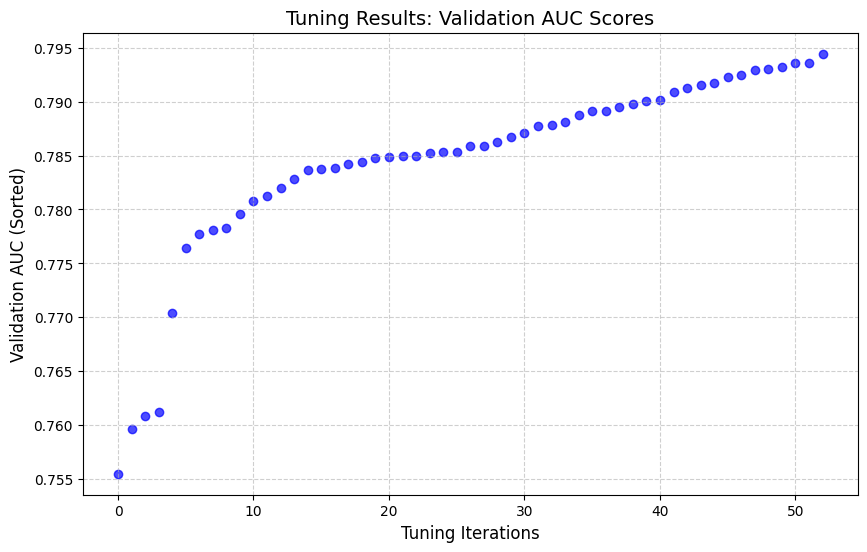

In [207]:
# Extract validation AUC scores
val_aucs = tuning_results_df['val_auc'].sort_values().values

# Generate x-axis values (just to separate the dots)
x_values = range(len(val_aucs))

# Plot the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(x_values, val_aucs, color='blue', alpha=0.7)
plt.title('Tuning Results: Validation AUC Scores', fontsize=14)
plt.xlabel('Tuning Iterations', fontsize=12)
plt.ylabel('Validation AUC (Sorted)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

We noted that hyperparameter tuning only marginally improve the final performance (validation accuracy to 0.795). This also confirmed our insights that feature engineering is more important than tuning in this type of task.

Load the best hyper parameter set

In [200]:
tuning_results_df = pd.read_csv("../results/tuning_results.csv")
best_params = tuning_results_df.dropna(axis=1).loc[tuning_results_df['val_auc'].idxmax()]
print(f"Best hyperparameters found with cross valid AUC {best_params['val_auc']}:")
best_params = best_params.drop(['val_auc', 'best_num_boost_round']).to_dict()
print(best_params)

Best hyperparameters found with cross valid AUC 0.7944348676770915:
{'boosting_type': 'goss', 'colsample_bytree': 0.8333333333333333, 'importance_type': 'split', 'learning_rate': 0.0305694866134644, 'max_depth': 4, 'min_child_samples': 175, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 1000, 'num_leaves': 198, 'random_state': 42.0, 'reg_alpha': 5.1020408163265305, 'reg_lambda': 0.8163265306122449, 'subsample': 1.0, 'subsample_for_bin': 100000, 'subsample_freq': 0, 'nthread': 4, 'verbosity': -1, 'max_bin': 100, 'is_unbalance': False}


Finally train using the best model and best feature set.

In [203]:
def retrain_model_w_best_params(train, test, params):
    train = train.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))
    test = test.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))

    train_y = train['TARGET']
    train_x = train.drop(['TARGET', 'SK_ID_CURR'], axis=1)
    test_x = test.drop(['SK_ID_CURR'], axis=1)

    # same train val split for model comparison
    train_x, valid_x, train_y, valid_y = train_test_split(train_x, train_y, test_size=0.2, random_state=42)

    # Convert float parameters that should be integers to integers
    for key, value in params.items():
        if isinstance(value, float) and value.is_integer():
            params[key] = int(value)
    clf = LGBMClassifier(**params)

    callbacks = [early_stopping(stopping_rounds=200)]
    clf.fit(train_x, train_y, eval_set=[(train_x, train_y), (valid_x, valid_y)], eval_metric= 'auc', callbacks=callbacks)

    # also compute test predictions
    pred = clf.predict_proba(test_x)[:, 1]

    # Submission dataframe
    submit = test[['SK_ID_CURR']].copy()
    submit.loc[:, 'TARGET'] = pred

    # Save the submission to a csv file
    submit.to_csv(f'../results/final_tuned_lgbm.csv', index = False)

    model_filename = f'../models/final_tuned_lgbm_model.pkl'
    pickle.dump(clf, open(model_filename, 'wb'))

    return clf

clf_final_lgbm = retrain_model_w_best_params(app_domain_train, app_domain_test, best_params)

Training until validation scores don't improve for 200 rounds
Did not meet early stopping. Best iteration is:
[994]	training's auc: 0.830773	training's binary_logloss: 0.221073	valid_1's auc: 0.79416	valid_1's binary_logloss: 0.233907


In [ ]:
# final post-processing: ensure SK_ID_CURR is int in all result files for kaggle submission

results_dir = "../results"

for file in os.listdir(results_dir):
    if file.endswith(".csv") and file != "tuning_results.csv":
        file_path = os.path.join(results_dir, file)
        df = pd.read_csv(file_path)
        
        if 'SK_ID_CURR' in df.columns:
            df['SK_ID_CURR'] = df['SK_ID_CURR'].astype(int)
            df.to_csv(file_path, index=False)

# 5. Interpretation

## Feature Importances

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

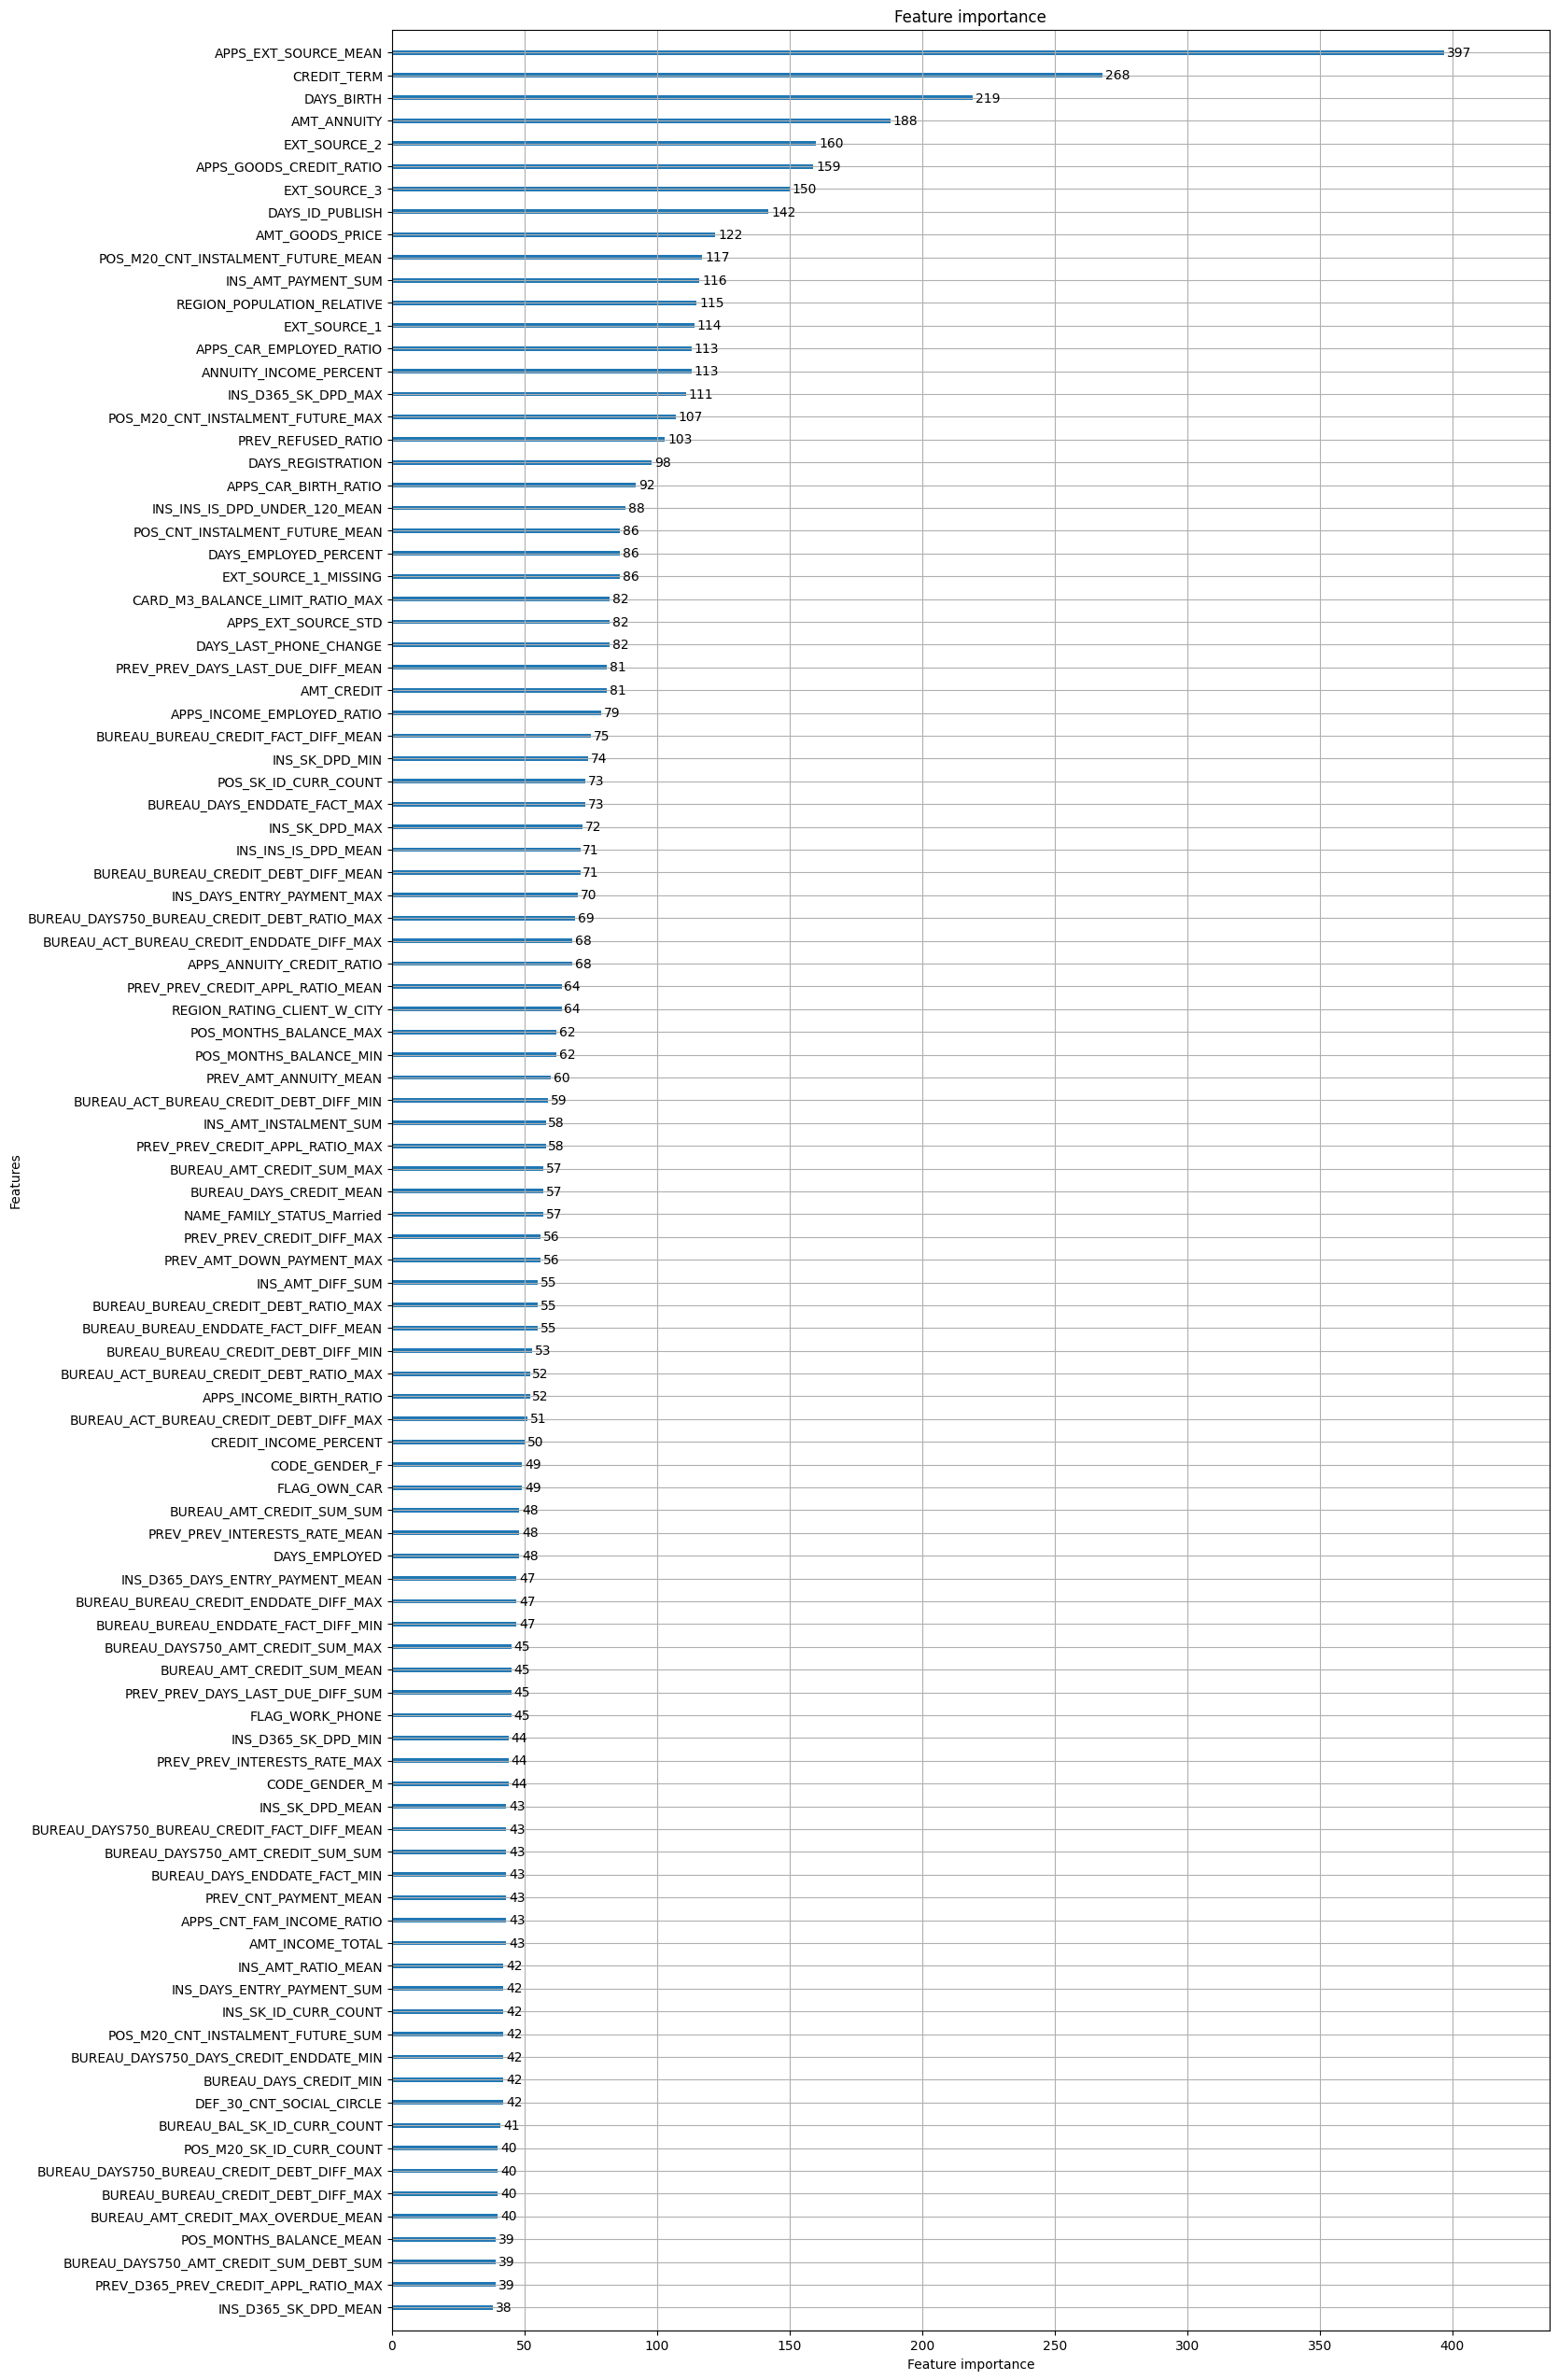

In [204]:
from lightgbm import plot_importance

plot_importance(clf_final_lgbm, figsize=(16, 32), max_num_features=100)

由以上可知，重要特征之间的相关性足够小以保证特征空间能够用多个特征诠释

# 5.4 Feature Selection Validated Using Automatic Feature Engineering

Featuretools Basics Featuretools 中的实体必须有一个唯一索引，其中没有任何元素重复。目前，只有 app、bureau 和 previous 拥有唯一索引（分别是 SK_ID_CURR、SK_ID_BUREAU 和 SK_ID_PREV）。对于其他数据框，我们必须传入 make_index = True，然后指定索引的名称。实体也可以有时间索引，其中每个条目由唯一时间标识。（数据中没有日期时间，但有相对时间，以月或日表示，我们可以考虑将其作为时间变量处理）。 EntitySet 是表及其之间关系的集合。使用 EntitySet 允许我们将多个表组合在一起，并比单独操作单表更快速地进行处理。

首先，我们将创建一个名为 clients 的空 EntitySet：

In [185]:
app_train_auto = pd.read_csv('data/application_train.csv').sort_values('SK_ID_CURR').reset_index(drop = True).loc[:1000, :]
app_test_auto = pd.read_csv('data/application_test.csv').sort_values('SK_ID_CURR').reset_index(drop = True).loc[:1000, :]
bureau_auto = pd.read_csv('data/bureau.csv').sort_values(['SK_ID_CURR', 'SK_ID_BUREAU']).reset_index(drop = True).loc[:1000, :]
bureau_balance_auto = pd.read_csv('data/bureau_balance.csv').sort_values('SK_ID_BUREAU').reset_index(drop = True).loc[:1000, :]
cash_auto = pd.read_csv('data/POS_CASH_balance.csv').sort_values(['SK_ID_CURR', 'SK_ID_PREV']).reset_index(drop = True).loc[:1000, :]
credit_auto = pd.read_csv('data/credit_card_balance.csv').sort_values(['SK_ID_CURR', 'SK_ID_PREV']).reset_index(drop = True).loc[:1000, :]
previous_auto = pd.read_csv('data/previous_application.csv').sort_values(['SK_ID_CURR', 'SK_ID_PREV']).reset_index(drop = True).loc[:1000, :]
installments_auto = pd.read_csv('data/installments_payments.csv').sort_values(['SK_ID_CURR', 'SK_ID_PREV']).reset_index(drop = True).loc[:1000, :]

In [186]:
# Add identifying column
app_train_auto['set'] = 'train'
app_test_auto['set'] = 'test'
app_test_auto["TARGET"] = np.nan

# one-hot encoding of categorical variables
app_train_new = pd.get_dummies(app_train_auto)
app_test_new = pd.get_dummies(app_test_auto)
bureau_new = pd.get_dummies(bureau_auto)
bureau_balance_new = pd.get_dummies(bureau_balance_auto)
cash_new = pd.get_dummies(cash_auto)
credit_new = pd.get_dummies(credit_auto)
previous_new = pd.get_dummies(previous_auto)
installments_new = pd.get_dummies(installments_auto)
# Append the dataframes
app = pd.concat([app_train_new, app_test_new], ignore_index = True)
app.head(10)

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,NAME_CONTRACT_TYPE_Cash loans,NAME_CONTRACT_TYPE_Revolving loans,CODE_GENDER_F,CODE_GENDER_M,FLAG_OWN_CAR_N,FLAG_OWN_CAR_Y,FLAG_OWN_REALTY_N,FLAG_OWN_REALTY_Y,NAME_TYPE_SUITE_Children,NAME_TYPE_SUITE_Family,NAME_TYPE_SUITE_Group of people,NAME_TYPE_SUITE_Other_A,NAME_TYPE_SUITE_Other_B,"NAME_TYPE_SUITE_Spouse, partner",NAME_TYPE_SUITE_Unaccompanied,NAME_INCOME_TYPE_Commercial associate,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_State servant,NAME_INCOME_TYPE_Working,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Incomplete higher,NAME_EDUCATION_TYPE_Lower secondary,NAME_EDUCATION_TYPE_Secondary / secondary special,NAME_FAMILY_STATUS_Civil marriage,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single / not married,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_Co-op apartment,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents,OCCUPATION_TYPE_Accountants,OCCUPATION_TYPE_Cleaning staff,OCCUPATION_TYPE_Cooking staff,OCCUPATION_TYPE_Core staff,OCCUPATION_TYPE_Drivers,OCCUPATION_TYPE_HR staff,OCCUPATION_TYPE_High skill tech staff,OCCUPATION_TYPE_IT staff,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Waiters/barmen staff,WEEKDAY_APPR_PROCESS_START_FRIDAY,WEEKDAY_APPR_PROCESS_START_MONDAY,WEEKDAY_APPR_PROCESS_START_SATURDAY,WEEKDAY_APPR_PROCESS_START_SUNDAY,WEEKDAY_APPR_PROCESS_START_THURSDAY,WEEKDAY_APPR_PROCESS_START_TUESDAY,WEEKDAY_APPR_PROCESS_START_WEDNESDAY,ORGANIZATION_TYPE_Advertising,ORGANIZATION_TYPE_Agriculture,ORGANIZATION_TYPE_Bank,ORGANIZATION_TYPE_Business Entity Type 1,ORGANIZATION_TYPE_Business Entity Type 2,ORGANIZATION_TYPE_Business Entity Type 3,ORGANIZATION_TYPE_Construction,ORGANIZATION_TYPE_Culture,ORGANIZATION_TYPE_Electricity,ORGANIZATI

In [187]:
import featuretools as ft
# Entity set with id applications
es = ft.EntitySet(id = 'clients')

现在我们来定义每个实体或数据表。如果数据有索引，我们需要传入索引；如果没有，则将 make_index 设置为 True。Featuretools 会自动推断变量的类型，但如果需要，我们也可以更改它们。例如，如果我们有一个用整数表示的分类变量，我们可能希望让 Featuretools 知道正确的类型

In [188]:
# Entities with a unique index
es = es.add_dataframe(dataframe_name = 'app', dataframe = app, index = 'SK_ID_CURR')

es = es.add_dataframe(dataframe_name = 'bureau', dataframe = bureau_new, index = 'SK_ID_BUREAU')

es = es.add_dataframe(dataframe_name = 'previous', dataframe = previous_new, index = 'SK_ID_PREV')

# Entities that do not have a unique index
es = es.add_dataframe(dataframe_name =  'bureau_balance', dataframe = bureau_balance_new, make_index = True, index = 'bureau_balance_index')

es = es.add_dataframe(dataframe_name = 'cash', dataframe = cash_new, make_index = True, index = 'cash_index')

es = es.add_dataframe(dataframe_name = 'installments', dataframe = installments_new, make_index = True, index = 'installments_index')

es = es.add_dataframe(dataframe_name = 'credit', dataframe = credit_new, make_index = True, index = 'credit_index')

In [190]:
print('Parent: app, Parent Variable: SK_ID_CURR\n\n', app.iloc[:, 111:115].head())
print('\nChild: bureau, Child Variable: SK_ID_CURR\n\n', bureau_new.iloc[10:30, :4].head())

Parent: app, Parent Variable: SK_ID_CURR

         FLAG_OWN_CAR_Y  FLAG_OWN_REALTY_N  FLAG_OWN_REALTY_Y  \
100002           False              False               True   
100003           False               True              False   
100004            True              False               True   
100006           False              False               True   
100007           False              False               True   

        NAME_TYPE_SUITE_Children  
100002                     False  
100003                     False  
100004                     False  
100006                     False  
100007                     False  

Child: bureau, Child Variable: SK_ID_CURR

          SK_ID_CURR  SK_ID_BUREAU  DAYS_CREDIT  CREDIT_DAY_OVERDUE
6158905      100002       6158905         -476                   0
6158906      100002       6158906        -1437                   0
6158907      100002       6158907        -1121                   0
6158908      100002       6158908         -645   

In [191]:
# Relationship between app and bureau
r_app_bureau = ft.Relationship(
    parent_dataframe_name='app', 
    parent_column_name='SK_ID_CURR',
    child_dataframe_name='bureau',
    child_column_name='SK_ID_CURR',
    entityset=es
)

# Relationship between bureau and bureau balance
r_bureau_balance = ft.Relationship(
    parent_dataframe_name='bureau', 
    parent_column_name='SK_ID_BUREAU',
    child_dataframe_name='bureau_balance',
    child_column_name='SK_ID_BUREAU',
    entityset=es
)
# Relationship between current app and previous apps
r_app_previous = ft.Relationship(
    parent_dataframe_name='app', 
    parent_column_name='SK_ID_CURR',
    child_dataframe_name='previous',
    child_column_name='SK_ID_CURR',
    entityset=es
)

# Relationships between previous apps and cash, installments, and credit
r_previous_cash = ft.Relationship( 
    parent_dataframe_name='previous', 
    parent_column_name='SK_ID_PREV',
    child_dataframe_name='cash',
    child_column_name='SK_ID_PREV',
    entityset=es
)
r_previous_installments = ft.Relationship(
    parent_dataframe_name='previous', 
    parent_column_name='SK_ID_PREV',
    child_dataframe_name='installments',
    child_column_name='SK_ID_PREV',
    entityset=es
)
r_previous_credit = ft.Relationship(
    parent_dataframe_name='previous', 
    parent_column_name='SK_ID_PREV',
    child_dataframe_name='credit',
    child_column_name='SK_ID_PREV',
    entityset=es
)

In [192]:
# Add in the defined relationships
es = es.add_relationships([r_app_bureau, r_bureau_balance, r_app_previous,
                           r_previous_cash, r_previous_installments, r_previous_credit])
# Print out the EntitySet
es

Entityset: clients
  DataFrames:
    app [Rows: 2002, Columns: 234]
    bureau [Rows: 1001, Columns: 24]
    previous [Rows: 1001, Columns: 136]
    bureau_balance [Rows: 1001, Columns: 7]
    cash [Rows: 1001, Columns: 12]
    installments [Rows: 1001, Columns: 9]
    credit [Rows: 1001, Columns: 26]
  Relationships:
    bureau.SK_ID_CURR -> app.SK_ID_CURR
    bureau_balance.SK_ID_BUREAU -> bureau.SK_ID_BUREAU
    previous.SK_ID_CURR -> app.SK_ID_CURR
    cash.SK_ID_PREV -> previous.SK_ID_PREV
    installments.SK_ID_PREV -> previous.SK_ID_PREV
    credit.SK_ID_PREV -> previous.SK_ID_PREV

通过先前记录将应用和现金关联。我们使用 SK_ID_PREV 建立先前记录（父节点）和现金（子节点）之间的关系，然后使用 SK_ID_CURR 建立应用（父节点）和先前记录（现在为子节点）之间的关系。这样，featuretools 就能够通过堆叠多个原语，从先前记录和现金中为应用生成特征。

### Feature Primitives
特征原语是应用于表或一组表以创建特征的操作。这些表示简单的计算，其中许多我们在手动特征工程中已经使用过，可以叠加在一起创建复杂的特征。特征原语分为两类：
聚合：将子数据点按照每个父项进行分组，然后计算统计量，如均值、最小值、最大值或标准差。例如，计算每个客户之前的最大贷款金额。聚合操作可以跨多张表使用表之间的关系。
转换：应用于单个表中的一个或多个列的操作。例如，可以取一列的绝对值，或者计算同一表中两列之间的差值。

In [193]:
# List the primitives in a dataframe
primitives = ft.list_primitives()
pd.options.display.max_colwidth = 100
primitives[primitives['type'] == 'aggregation'].head(10)

,name,type,description,valid_inputs,return_type
0,std,aggregation,"Computes the dispersion relative to the mean value, ignoring `NaN`.",<ColumnSchema (Semantic Tags = ['numeric'])>,<ColumnSchema (Semantic Tags = ['numeric'])>
1,avg_time_between,aggregation,Computes the average number of seconds between consecutive events.,<ColumnSchema (Logical Type = Datetime) (Semantic Tags = ['time_index'])>,<ColumnSchema (Logical Type = Double) (Semantic Tags = ['numeric'])>
2,is_unique,aggregation,Determines whether or not a series of discrete is all unique.,<ColumnSchema (Semantic Tags = ['category'])>,<ColumnSchema (Logical Type = BooleanNullable)>
3,mode,aggregation,Determines the most commonly repeated value.,<ColumnSchema (Semantic Tags = ['category'])>,None
4,is_monotonically_decreasing,aggregation,Determines if a series is monotonically decreasing.,<ColumnSchema (Semantic Tags = ['numeric'])>,<ColumnSchema (Logical Type = BooleanNullable)>
5,percent_unique,aggregation,Determines the percent of unique values.,<ColumnSchema (Semantic Tags = ['category'])>,<ColumnSchema (Logical Type = Double) (Semantic Tags = ['numeric'])>
6,count_inside_range,aggregation,Determines the number of values that fall within a certain range.,<ColumnSchema (Semantic Tags = ['numeric'])>,<ColumnSchema (Logical Type = IntegerNullable) (Semantic Tags = ['numeric'])>
7,first_last_time_delta,aggregation,Determines the time between the first and last time value in seconds.,<ColumnSchema (Logical Type = Datetime) (Semantic Tags = ['time_index'])>,<ColumnSchema (Logical Type = Double) (Semantic Tags = ['numeric'])>
8,min_count,aggregation,Calculates the number of occurrences of the min value in a list,<ColumnSchema (Semantic Tags = ['numeric'])>,<ColumnSchema (Logical Type = IntegerNullable) (Semantic Tags = ['numeric'])>
9,num_false_since_last_true,aggregation,Calculates the number of 'False' values since the last `True` value. Description: From a series ...,<ColumnSchema (Logical Type = Boolean)>,<ColumnSchema (Logical Type = IntegerNullable) (Semantic Tags = ['numeric'])>


### Deep Feature Synthesis
深度特征合成（DFS）是 featuretools 用来创建新特征的过程。DFS 通过堆叠特征基元来形成特征，其“深度”等于基元的数量。例如，如果我们取客户以前贷款的最大值（例如 MAX(previous.loan_amount)），这就是一个深度为 1 的“深度特征”。要创建深度为 2 的特征，我们可以通过堆叠基元来实现，例如取客户每笔以前贷款的平均每月付款的最大值（如 MAX(previous(MEAN(installments.payment)))）。关于使用深度特征合成进行自动化特征工程的原始论文值得一读。

在 Featuretools 中执行 DFS（深度优先特征生成）时，我们使用 dfs 函数，并传入一个实体集合（entityset）、目标实体（target_entity，即我们希望生成特征的实体）、要使用的聚合原语（agg_primitives）、要使用的转换原语（trans_primitives）以及特征的最大深度（max_depth）。这里我们将使用默认的聚合和转换原语，最大深度为 2，并为 app 实体计算原语。由于这个过程计算量很大，我们可以通过设置 features_only = True 来运行函数，仅返回特征列表，而不实际计算特征本身。这在开始长时间计算之前查看生成的特征时非常有用。

#### DFS with Default Primitives

In [194]:
# Default primitives from featuretools
default_agg_primitives =  ["sum", "std", "max", "skew", "min", "mean", "count", "percent_true", "num_unique", "mode"]
default_trans_primitives =  ["day", "year", "month", "weekday", "haversine"]

# DFS with specified primitives
feature_names = ft.dfs(entityset = es, target_dataframe_name = 'app',
                       trans_primitives = default_trans_primitives,
                       agg_primitives=default_agg_primitives, 
                       max_depth = 2, features_only=True)

print('%d Total Features' % len(feature_names))

2711 Total Features


In [195]:
# DFS with default primitives
feature_matrix, feature_names = ft.dfs(entityset = es, target_dataframe_name = 'app',
                                       trans_primitives = default_trans_primitives,
                                       agg_primitives=default_agg_primitives, 
                                        max_depth = 2, features_only=False, verbose = True)

pd.options.display.max_columns = 1700
feature_matrix.head(10)

Built 2711 features
Elapsed: 00:08 | Progress: 100%|███████████████████████████████████████████████████████████████████████████████████████


TARGET  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
SK_ID_CURR                                                                    
100002           1             0          202500.0    406597.5      24700.5   
100003           0             0          270000.0   1293502.5      35698.5   
100004           0             0           67500.0    135000.0       6750.0   
100006           0             0          135000.0    312682.5      29686.5   
100007           0             0          121500.0    513000.0      21865.5   
100008           0             0           99000.0    490495.5      27517.5   
100009           0             1          171000.0   1560726.0      41301.0   
100010           0             0          360000.0   1530000.0      42075.0   
100011           0             0          112500.0   1019610.0      33826.5   
100012           0             0          135000.0    405000.0      20250.0   

            AMT_GOODS_PRICE  REGION_POPULATION_RELATIVE  DAYS_BIRTH  \
SK_ID_CURR                                                            
100002             351000.0                    0.018801       -9461   
100003            1129500.0                    0.003541      -16765   
100004             135000.0                    0.010032      -19046   
100006             297000.0                    0.008019      -19005   
100007             513000.0                    0.028663      -19932   
100008             454500.0                    0.035792      -16941   
100009            1395000.0                    0.035792      -13778   
100010            1530000.0                    0.003122      -18850   
100011             913500.0                    0.018634      -20099   
100012             405000.0                    0.019689      -14469   

            DAYS_EMPLOYED  DAYS_REGISTRATION  DAYS_ID_PUBLISH  OWN_CAR_AGE  \
SK_ID_CURR                                                                   
100002               -637            -3648.0            -2120         <NA>   
100003              -1188            -1186.0             -291         <NA>   
100004               -225            -4260.0            -2531           26   
100006              -3039            -9833.0            -2437         <NA>   
100007              -3038            -4311.0            -3458         <NA>   
100008              -1588            -4970.0             -477         <NA>   
100009              -3130            -1213.0             -619           17   
100010               -449            -4597.0            -2379            8   
100011             365243            -7427.0            -3514         <NA>   
100012              -2019           -14437.0            -3992         <NA>   

            FLAG_MOBIL  FLAG_EMP_PHONE  FLAG_WORK_PHONE  FLAG_CONT_MOBILE  \
SK_ID_CURR                                                                  
100002               1               1                0                 1   
100003               1               1                0                 1   
100004               1               1                1                 1   
100006               1               1                0                 1   
100007               1               1                0                 1   
100008               1               1                1                 1   
100009               1               1                0                 1   
100010               1               1                1                 1   
100011               1               0                0                 1   
100012               1               1                0                 1   

            FLAG_PHONE  FLAG_EMAIL  CNT_FAM_MEMBERS  REGION_RATING_CLIENT  \
SK_ID_CURR                                                                  
100002               1           0              1.0                     2   
100003               1           0              2.0                     1   
100004               1           0      

#### DFS with Selected Aggregation Primitives
通过featuretools，我们能够在几行代码中将121个原始特征扩展到近2700个。当我手动进行特征工程时，创建一个可比较大小的数据集大约需要12小时。然而，虽然我们在featuretools中获得了很多特征，这个函数调用的信息量并不大。我们只是使用了默认的聚合方法，而没有考虑哪些对问题是“重要的”。我们最终会得到很多特征，但它们可能并非全部与问题相关。过多无关的特征可能会降低性能，因为它们会淹没重要特征（与维度灾难相关）。接下来我们将调用的函数会指定一组较小的特征。我们仍然没有使用太多领域知识，但这组特征会更易于管理。下一步是改进我们实际创建的特征并进行特征选择。

In [196]:
# Specify the aggregation primitives
feature_matrix_spec, feature_names_spec = ft.dfs(entityset = es, target_dataframe_name = 'app',  
                                                 agg_primitives = ['sum', 'count', 'min', 'max', 'mean', 'mode'], 
                                                 max_depth = 2, features_only = False, verbose = True)

Built 1246 features
Elapsed: 00:01 | Progress: 100%|███████████████████████████████████████████████████████████████████████████████████████


In [197]:
# 给了我们1246个特征
pd.options.display.max_columns = 1000
feature_matrix_spec.head(10)

TARGET  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
SK_ID_CURR                                                                    
100002           1             0          202500.0    406597.5      24700.5   
100003           0             0          270000.0   1293502.5      35698.5   
100004           0             0           67500.0    135000.0       6750.0   
100006           0             0          135000.0    312682.5      29686.5   
100007           0             0          121500.0    513000.0      21865.5   
100008           0             0           99000.0    490495.5      27517.5   
100009           0             1          171000.0   1560726.0      41301.0   
100010           0             0          360000.0   1530000.0      42075.0   
100011           0             0          112500.0   1019610.0      33826.5   
100012           0             0          135000.0    405000.0      20250.0   

            AMT_GOODS_PRICE  REGION_POPULATION_RELATIVE  DAYS_BIRTH  \
SK_ID_CURR                                                            
100002             351000.0                    0.018801       -9461   
100003            1129500.0                    0.003541      -16765   
100004             135000.0                    0.010032      -19046   
100006             297000.0                    0.008019      -19005   
100007             513000.0                    0.028663      -19932   
100008             454500.0                    0.035792      -16941   
100009            1395000.0                    0.035792      -13778   
100010            1530000.0                    0.003122      -18850   
100011             913500.0                    0.018634      -20099   
100012             405000.0                    0.019689      -14469   

            DAYS_EMPLOYED  DAYS_REGISTRATION  DAYS_ID_PUBLISH  OWN_CAR_AGE  \
SK_ID_CURR                                                                   
100002               -637            -3648.0            -2120         <NA>   
100003              -1188            -1186.0             -291         <NA>   
100004               -225            -4260.0            -2531           26   
100006              -3039            -9833.0            -2437         <NA>   
100007              -3038            -4311.0            -3458         <NA>   
100008              -1588            -4970.0             -477         <NA>   
100009              -3130            -1213.0             -619           17   
100010               -449            -4597.0            -2379            8   
100011             365243            -7427.0            -3514         <NA>   
100012              -2019           -14437.0            -3992         <NA>   

            FLAG_MOBIL  FLAG_EMP_PHONE  FLAG_WORK_PHONE  FLAG_CONT_MOBILE  \
SK_ID_CURR                                                                  
100002               1               1                0                 1   
100003               1               1                0                 1   
100004               1               1                1                 1   
100006               1               1                0                 1   
100007               1               1                0                 1   
100008               1               1                1                 1   
100009               1               1                0                 1   
100010               1               1                1                 1   
100011               1               0                0                 1   
100012               1               1                0                 1   

            FLAG_PHONE  FLAG_EMAIL  CNT_FAM_MEMBERS  REGION_RATING_CLIENT  \
SK_ID_CURR                                                                  
100002               1           0              1.0                     2   
100003               1           0              2.0                     1   
100004               1           0      

### 结果分析
为了确定我们对 featuretools 的基础实现是否有用，我们可以查看几个结果：
使用几组不同特征的交叉验证得分和公开排行榜得分。
相关性：既包括特征与目标（TARGET）之间的相关性，也包括特征之间的相关性。
特征重要性：由梯度提升机模型确定。

#### Feature Performance Experiments
为了比较多种不同的特征集在机器学习任务中的表现，为了单独分析特征的影响，所有实验均使用相同的模型来测试不同的特征集。该模型是一种基本的 LightGBM 算法，使用 5 折交叉验证进行训练和评估。
首先，我们建立一个对照数据集，然后进行一系列实验并展示结果。
对照组：仅使用应用数据集的数据
实验一：仅使用应用、信贷局（bureau）和信贷局余额（bureau_balance）数据进行手动特征工程
实验二：使用所有数据集进行手动特征工程
实验三：使用 featuretools 的默认特征（在 feature_matrix 中）
实验四：使用 featuretools 指定特征（在 feature_matrix_spec 中）
实验五：将 featuretools 指定特征与手动特征工程结合使用

在理想情况下，我们希望拥有一组相互独立的特征，但在实际中这种情况很少发生。如果存在高度相关的变量，我们可能需要考虑删除其中的一些。对于相关性分析，我们将集中在feature_matrix_spec上，即我们通过指定原始函数生成的特征。

In [215]:
# Threshold for removing correlated variables
threshold = 0.9
#feature_matrix_spec = feature_matrix_spec.astype(float)
# Absolute value correlation matrix
corr_matrix = feature_matrix_spec.corr().abs()
corr_matrix.head()

,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,NAME_CONTRACT_TYPE_Cash loans,NAME_CONTRACT_TYPE_Revolving loans,CODE_GENDER_F,CODE_GENDER_M,FLAG_OWN_CAR_N,FLAG_OWN_CAR_Y,FLAG_OWN_REALTY_N,FLAG_OWN_REALTY_Y,NAME_TYPE_SUITE_Children,NAME_TYPE_SUITE_Family,NAME_TYPE_SUITE_Group of people,NAME_TYPE_SUITE_Other_A,NAME_TYPE_SUITE_Other_B,"NAME_TYPE_SUITE_Spouse, partner",NAME_TYPE_SUITE_Unaccompanied,NAME_INCOME_TYPE_Commercial associate,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_State servant,NAME_INCOME_TYPE_Working,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Incomplete higher,NAME_EDUCATION_TYPE_Lower secondary,NAME_EDUCATION_TYPE_Secondary / secondary special,NAME_FAMILY_STATUS_Civil marriage,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single / not married,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_Co-op apartment,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents,OCCUPATION_TYPE_Accountants,OCCUPATION_TYPE_Cleaning staff,OCCUPATION_TYPE_Cooking staff,OCCUPATION_TYPE_Core staff,OCCUPATION_TYPE_Drivers,OCCUPATION_TYPE_HR staff,OCCUPATION_TYPE_High skill tech staff,OCCUPATION_TYPE_IT staff,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Waiters/barmen staff,WEEKDAY_APPR_PROCESS_START_FRIDAY,WEEKDAY_APPR_PROCESS_START_MONDAY,WEEKDAY_APPR_PROCESS_START_SATURDAY,WEEKDAY_APPR_PROCESS_START_SUNDAY,WEEKDAY_APPR_PROCESS_START_THURSDAY,WEEKDAY_APPR_PROCESS_START_TUESDAY,WEEKDAY_APPR_PROCESS_START_WEDNESDAY,ORGANIZATION_TYPE_Advertising,ORGANIZATION_TYPE_Agriculture,ORGANIZATION_TYPE_Bank,ORGANIZATION_TYPE_Business Entity Type 1,ORGANIZATION_TYPE_Business Entity Type 2,ORGANIZATION_TYPE_Business Entity Type 3,ORGANIZATION_TYPE_Construction,ORGANIZATION_TYPE_Culture,ORGANIZATION_TYPE_Electricity,ORGANIZATION_TYPE_Eme

In [252]:
# 在PCA之前检查数据
print("原始数据形状:", feature_matrix_spec.shape)
print("原始数据类型:", type(feature_matrix_spec))

原始数据形状: (2002, 1246)
原始数据类型: <class 'pandas.core.frame.DataFrame'>


In [ ]:
# 选择主要成分(PCA),m=30
m=30
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline

def pca_with_feature_names(data, n_components=None):
    """
    带列名的主成分分析
    
    参数:
    data: 包含列名的DataFrame
    n_components: 主成分数量，如果为None则自动选择累计贡献率>85%的成分
    """
    
    # 保存原始列名
    original_columns = data.columns.tolist()
    original_index = data.index
    print(f"原始数据有 {len(original_columns)} 个变量: {original_columns}")
    
    # 1. 数据预处理前的清理
    data_clean = data.copy()
    
    # 删除全为NaN的列
    nan_columns = data_clean.columns[data_clean.isna().all()]
    if len(nan_columns) > 0:
        print(f"删除全NaN列: {len(nan_columns)} 列")
        data_clean = data_clean.drop(columns=nan_columns)
    
    # 删除常数列
    constant_columns = data_clean.columns[data_clean.nunique() <= 1]
    if len(constant_columns) > 0:
        print(f"删除常数列: {len(constant_columns)} 列")
        data_clean = data_clean.drop(columns=constant_columns)
    
    # 处理无穷值
    inf_mask = np.isinf(data_clean)
    if inf_mask.any().any():
        print("处理无穷值...")
        data_clean = data_clean.replace([np.inf, -np.inf], np.nan)
    
    print(f"清理后数据: {data_clean.shape[0]} 行 × {data_clean.shape[1]} 列")
    remaining_columns = data_clean.columns.tolist()
    
    # 创建预处理pipeline
    preprocessor = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    # 应用预处理
    data_processed = preprocessor.fit_transform(data_clean)
    
    # 重新创建DataFrame以保持列名
    data_processed_df = pd.DataFrame(
        data_processed, 
        columns=remaining_columns,
        index=original_index
    )
    
    # 2、使用PCA进行主成分分析
    if n_components is None:
        # 先拟合所有成分来决定数量
        pca_full = PCA()
        pca_full.fit(data_processed_df)
        
        # 计算累计贡献率
        cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
        
        # 自动选择累计贡献率>85%的成分
        n_components = np.argmax(cumulative_variance >= 0.85) + 1
        print(f"自动选择 {n_components} 个主成分，累计贡献率: {cumulative_variance[n_components-1]:.3f}")
    
    pca = PCA(n_components=n_components)
    principal_components = pca.fit_transform(data_processed_df)
    
    # 3、输出PCA结果信息
    print("\n" + "="*50)
    print("PCA分析结果")
    print("="*50)
    
    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_explained_variance_ratio = np.cumsum(explained_variance_ratio)
    
    print(f'各主成分贡献率: {explained_variance_ratio}')
    print(f'累计贡献率: {cumulative_explained_variance_ratio}')
    
    components_df = pd.DataFrame(
        pca.components_.T,
        index=remaining_columns,  # 使用实际剩余的列名
        columns=[f'主成分{i+1}' for i in range(n_components)]
    )
    
    # 5、为主成分生成有意义的名称
    def generate_component_name(component_series, top_n=3):
        """为主成分生成描述性名称"""
        # 取系数绝对值最大的top_n个特征
        top_features = component_series.abs().nlargest(top_n)
        
        features_with_direction = []
        for feature in top_features.index:
            coef = component_series[feature]
            direction = "(+)" if coef > 0 else "(-)"
            features_with_direction.append(f"{feature}{direction}")
        
        return " + ".join(features_with_direction)
    
    # 生成新的主成分名称
    new_component_names = []
    for i in range(n_components):
        component = components_df.iloc[:, i]
        component_name = generate_component_name(component)
        new_component_names.append(f'PC{i+1}: {component_name}')
    
    print("\n主成分解释:")
    for i, name in enumerate(new_component_names):
        print(f"主成分{i+1}: {name}")
    
    # 6、创建降维后的DataFrame（使用有意义的列名）
    principal_df = pd.DataFrame(
        data=principal_components,
        index=data.index,
        columns=new_component_names
    )
    
    # 7、可视化结果
    plt.figure(figsize=(30, 10))
    
    # 子图1：贡献率图
    plt.subplot(1, 3, 1)
    plt.bar(range(1, n_components+1), explained_variance_ratio, alpha=0.6, color='skyblue')
    plt.plot(range(1, n_components+1), cumulative_explained_variance_ratio, 'ro-')
    plt.xlabel('主成分')
    plt.ylabel('方差解释率')
    plt.title('主成分贡献率')
    plt.legend(['累计贡献率', '单个贡献率'])
    
#     # 子图2：主成分系数热图
#     plt.subplot(1, 3, 2)
#     im = plt.imshow(components_df.values, cmap='RdBu_r', aspect='auto')
#     plt.colorbar(im, label='系数值')
#     plt.xticks(range(n_components), [f'PC{i+1}' for i in range(n_components)], rotation=45)
#     plt.yticks(range(len(remaining_columns)), remaining_columns)
#     plt.title('主成分系数热图')
    
    # 子图3：前两个主成分的散点图
    plt.subplot(1, 3, 3)
    if n_components >= 2:
        plt.scatter(principal_components[:, 0], principal_components[:, 1], alpha=0.7)
        plt.xlabel(new_component_names[0])
        plt.ylabel(new_component_names[1])
        plt.title('前两个主成分散点图')
    
    plt.tight_layout()
    plt.show()
    
    return principal_df, components_df, pca

原始数据有 1246 个变量: ['TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YE

自动选择 80 个主成分，累计贡献率: 0.851

PCA分析结果
各主成分贡献率: [0.13645353 0.09877931 0.06222045 0.04347686 0.03927971 0.03427897
 0.02796597 0.02562826 0.02160469 0.02100976 0.01924909 0.01864676
 0.01768472 0.01476908 0.0134948  0.01313935 0.01209081 0.01086022
 0.01053956 0.00949713 0.00860971 0.00751213 0.00706957 0.00669611
 0.00655334 0.00616134 0.00591047 0.00573875 0.00536861 0.00528107
 0.00498683 0.00480867 0.00467639 0.00450955 0.00432074 0.00413038
 0.00393814 0.00389779 0.00385773 0.00363285 0.00354491 0.00348323
 0.00331934 0.00323896 0.00318864 0.00309456 0.00301761 0.00292315
 0.00284501 0.00275162 0.00272088 0.00265925 0.00263755 0.0025431
 0.00248589 0.00242264 0.00237548 0.00234618 0.00229095 0.00226885
 0.00219839 0.00214922 0.00211257 0.00206555 0.00204897 0.00199415
 0.00191637 0.0018734  0.00185032 0.00182445 0.00179692 0.00178192
 0.00172237 0.00169995 0.00166776 0.00165732 0.00162988 0.001602
 0.00158001 0.00156339]
累计贡献率: [0.13645353 0.23523283 0.29745328 0.34093014 0.38020985 0

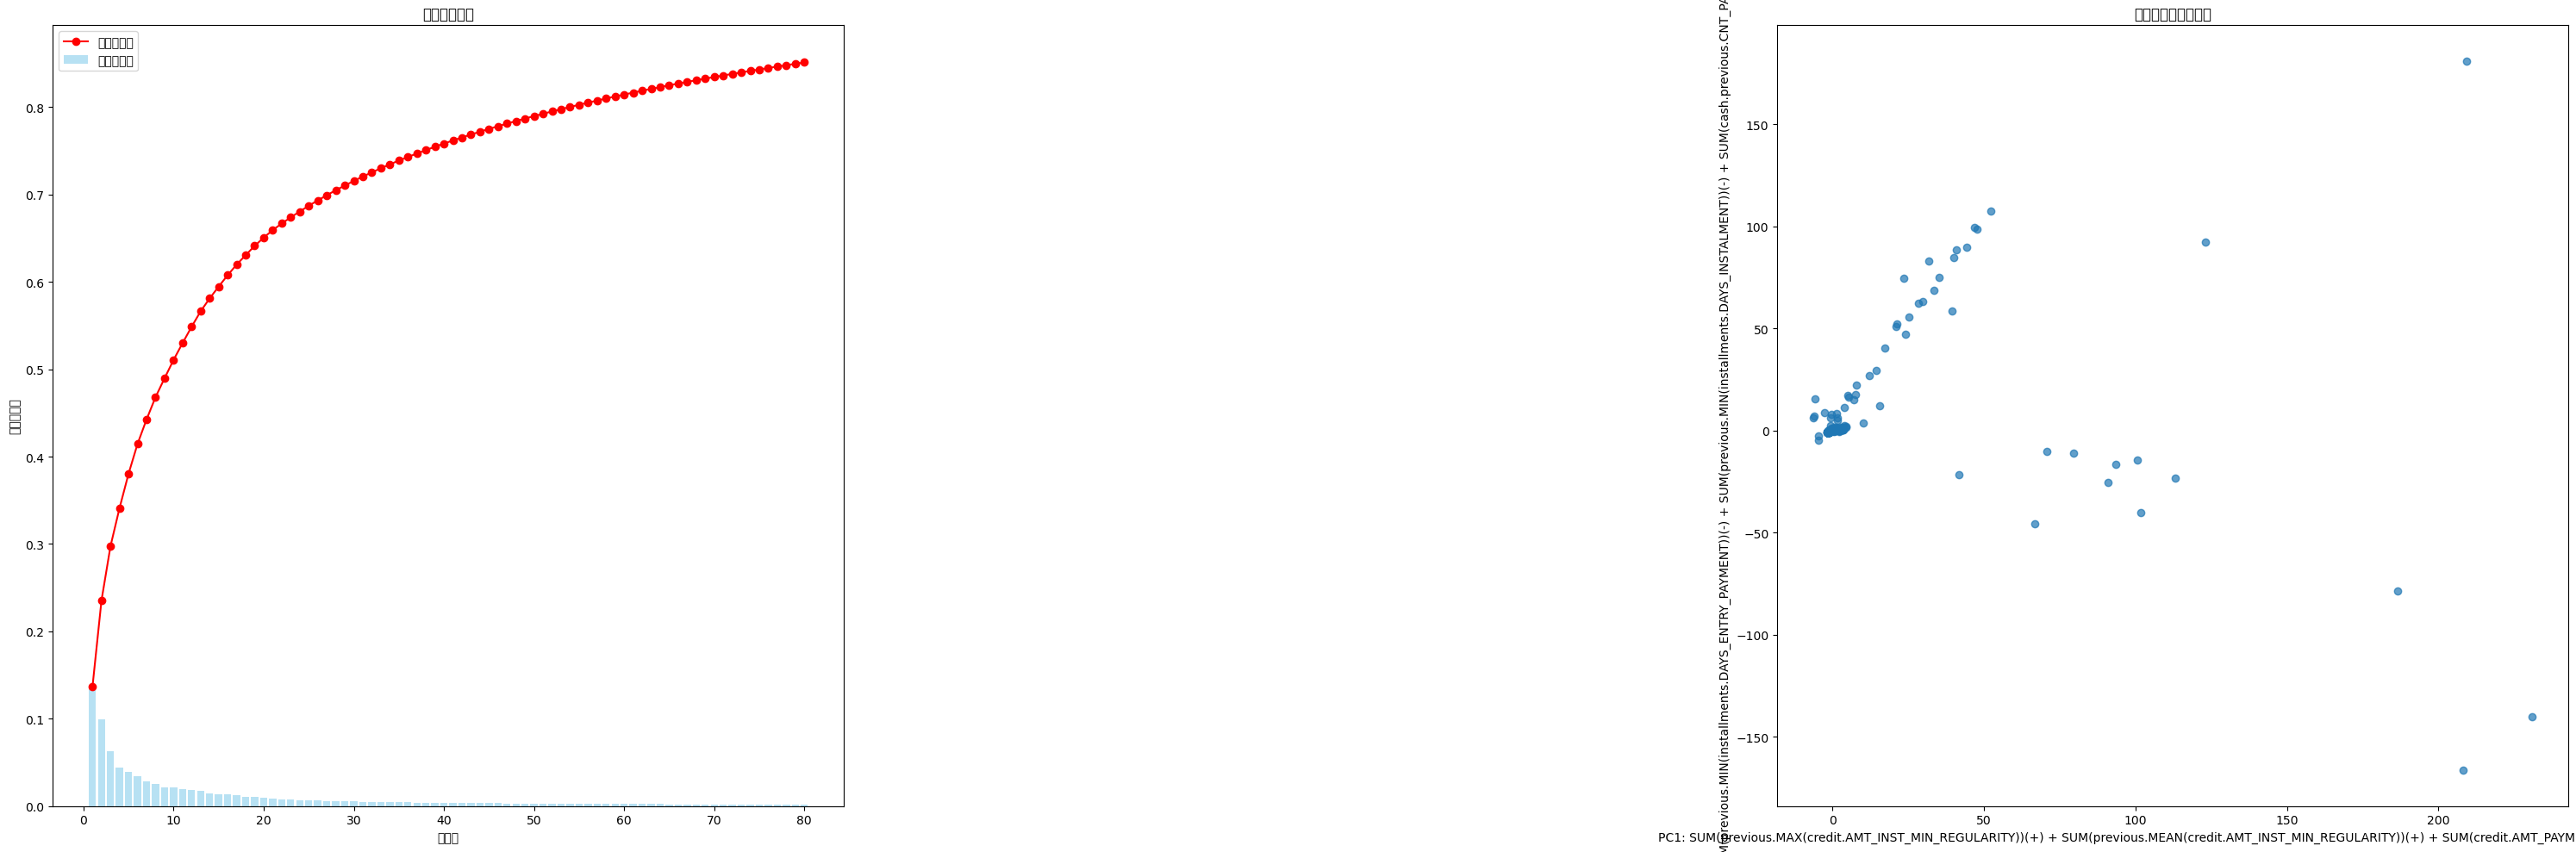


主成分系数详情:
                                主成分1      主成分2      主成分3      主成分4      主成分5  \
TARGET                     -0.000093 -0.000002  0.001013  0.004060  0.000505   
CNT_CHILDREN                0.001786 -0.000799 -0.006693  0.002439 -0.000680   
AMT_INCOME_TOTAL            0.001149  0.000511 -0.002935  0.006561 -0.000173   
AMT_CREDIT                  0.001813  0.005711 -0.003872  0.001367 -0.000164   
AMT_ANNUITY                -0.000814  0.002712 -0.002132  0.001746 -0.001138   
AMT_GOODS_PRICE             0.001714  0.005638 -0.003714  0.001355 -0.000295   
REGION_POPULATION_RELATIVE  0.001059 -0.001411  0.000940  0.001643 -0.008386   
DAYS_BIRTH                 -0.000183 -0.000518  0.001199  0.005060  0.003608   
DAYS_EMPLOYED              -0.001494  0.001006 -0.000434 -0.008497 -0.001400   
DAYS_REGISTRATION           0.001673  0.001686 -0.001093 -0.000534 -0.000288   

                                主成分6      主成分7      主成分8      主成分9     主成分10  \
TARGET                      0

In [308]:
# 执行PCA分析
principal_df, components_df, pca_model = pca_with_feature_names(feature_matrix_spec)

# print("\n降维后的数据:")
# print(principal_df.head(10))

print("\n主成分系数详情:")
print(components_df.head(10))